<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 2 v2.0. MODELO RANDOM FOREST DE VARIABLES ACÚSTICAS Y DEMOGRÁFICAS CON VALIDACIÓN PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook y relación con los notebooks anteriores
        <br>
        2. Configuración técnica y variables globales
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. SÍNTESIS DE HALLAZGOS DEL NOTEBOOK 1 (VALIDACIÓN DEL DATASET)
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Resumen demográfico relevante para el modelado
        <br>
        4. Hipótesis previa: ¿Predictores genuinos o confusores?
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. CARGA DE DATOS, SPLITS Y RESULTADOS BASELINE
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    5. Carga del dataset y del split pre-generado
        <br>
    6. Carga de resultados del modelo baseline (Notebook 2 v1.0)
        <br>
    7. Verificación de consistencia entre notebooks 
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. MODELO EXTENDIDO (VARIABLES ACÚSTICAS + DEMOGRÁFICAS)
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    8. Estrategia de incorporación demográfica y justificación
        <br>
    9. Definición del problema supervisado extendido
        <br>
    10. Pipeline de preprocesamiento extendido
        <br>
11. Nested Cross-Validation extendido
        <br>
    12. Entrenamiento del modelo final extendido
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. EVALUACIÓN DEL MODELO EXTENDIDO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    13. Evaluación en Validation Set
        <br>
    14. Análisis FP/FN en Validation
        <br>
    15. Importancia de variables (Permutation Importance y MDI)
        <br>
16. Evaluación en Test Set
        <br>
    17. Análisis FP/FN en Test
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. COMPARATIVA CON EL MODELO BASELINE
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    18. Tabla comparativa de métricas (v1.0 vs v2.0)
        <br>
    19. Comparación de errores FP/FN
        <br>
    20. Ranking de AGE y SEX vs Features Acústicas
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. EVALUACIÓN DE SESGO Y CONFUSIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    21. ¿AGE/SEX como proxy de diagnóstico?
        <br>
22. Conexión entre validación y comportamiento del modelo
        <br>
    

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>


<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    23. Resumen de las conclusiones finales
        <br>
    24. Tabla resumen final
        <br>
        <br>
    

---


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook y relación con los notebooks anteriores</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook desarrolla la segunda versión del modelo Random Forest para clasificación binaria ALS vs. HC, y constituye la iteración metodológicamente más completa del pipeline de modelado clásico del proyecto. A diferencia del Notebook 2 v1.0, que se limitaba al espacio de las 50 variables acústicas, este notebook explora el efecto de incorporar variables demográficas como predictores adicionales, evalúa empíricamente si dicha incorporación mejora el rendimiento y cuantifica la contribución relativa de cada tipo de información al modelo final.
<br><br>
La relación con los notebooks anteriores es la siguiente. El <b>Notebook 1</b> estableció que el dataset VOC-ALS no presenta sesgos demográficos significativos entre clases (edad p = 0.857, sexo p > 0.05), lo que descarta que las variables demográficas actúen como proxies directos del diagnóstico. Sin embargo, esta homogeneidad entre grupos no implica que la edad o el sexo carezcan de valor predictivo: la frecuencia fundamental de la voz (F0) disminuye con la edad y difiere sistemáticamente entre hombres y mujeres, por lo que ambas variables pueden interactuar con las features acústicas y mejorar la capacidad discriminativa del modelo en presencia de variabilidad demográfica intra-grupo. El <b>Notebook 2 v1.0</b> demostró que un modelo exclusivamente acústico con nested CV y selección de features alcanzaba un rendimiento moderado (balanced accuracy ≈ 0.55, AUC ≈ 0.57 en nested CV), estableciendo el punto de partida cuantitativo frente al que se medirán las mejoras de esta versión.
<br><br>
El objetivo central de este notebook es responder a tres preguntas concretas:
<ol>
<li>¿Incorporar variables demográficas (edad y sexo) mejora el rendimiento del modelo respecto al baseline acústico?</li>
<li>¿Qué variables (acústicas o demográficas) tienen mayor importancia en el modelo extendido?</li>
<li>¿El modelo extendido comete errores distintos al baseline? ¿Cambia el perfil de FP y FN?</li>
</ol>
    </span> 
</div>

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

In [59]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, balanced_accuracy_score, roc_curve
)
from sklearn.inspection import permutation_importance
from scipy.stats import mannwhitneyu, chi2_contingency

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Librerías importadas correctamente")
print(f"  Python:       {sys.version.split()[0]}")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")

Librerías importadas correctamente
  Python:       3.13.0
  NumPy:        2.4.2
  Pandas:       2.3.3
  Scikit-learn: 1.8.0


In [60]:
# VARIABLES GLOBALES Y RUTAS
DATASET_PATH  = r"C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx"
SPLIT_PATH    = r"C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv"

# Resultados del Notebook 2 v1.0 (baseline)
BASELINE_RESULTS_PATH = Path(r"C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0")

# Resultados de este notebook
RESULTS_PATH = Path(r"C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v2.0")
# RESULTS_PATH.mkdir(parents=True, exist_ok=True)

SHEET_NAME = "VOC-ALS_Data"
TARGET     = "Category"   # ALS / HC
ID_COL     = "ID"
AGE_COL    = "Age (years)"
SEX_COL    = "Sex"

PALETTE = {"ALS": "#E24B4A", "HC": "#378ADD"}

MLFLOW_EXPERIMENT_NAME = "Model_RF_Final_v2"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Configuración cargada")
print(f"  Dataset:          {DATASET_PATH}")
print(f"  Split:            {SPLIT_PATH}")
print(f"  Baseline results: {BASELINE_RESULTS_PATH}")
print(f"  Results:          {RESULTS_PATH}")
print(f"  MLflow:           {MLFLOW_EXPERIMENT_NAME}")

Configuración cargada
  Dataset:          C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx
  Split:            C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv
  Baseline results: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0
  Results:          C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v2.0
  MLflow:           Model_RF_Final_v2


#
---
#


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. SÍNTESIS DE HALLAZGOS DEL NOTEBOOK 1 (VALIDACIÓN DEL DATASET)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de construir el modelo extendido, es imprescindible recuperar y documentar los hallazgos del Notebook 1 que tienen implicaciones directas sobre las decisiones de diseño de este experimento. Este bloque no repite el análisis ya realizado, sino que sintetiza sus conclusiones en los dos ejes relevantes para el modelado: el perfil demográfico del dataset y la hipótesis sobre la naturaleza de los predictores acústicos.
    </span> 
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Resumen demográfico relevante para el modelado</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El Notebook 1 estableció que la distribución de edad y sexo es estadísticamente homogénea entre los grupos ALS y HC. La edad media es prácticamente idéntica en ambos grupos (ALS ≈ 62.8 años, HC ≈ 63.0 años), con una diferencia no significativa (Mann-Whitney p = 0.857, Cohen's d = −0.02). La distribución de sexo tampoco difiere entre grupos (Chi² p > 0.05). Estos resultados son recogidos aquí porque condicionan la interpretación de los resultados de este notebook: si el modelo extendido mejora al incorporar demografía, la ganancia no procede de que la demografía discrimine directamente entre diagnósticos (ya sabemos que no lo hace), sino de que ayuda al modelo a controlar la variabilidad acústica intra-individuo ligada a la edad y el sexo.
<br><br>
Un hallazgo adicional relevante del Notebook 1 es el patrón de colinealidad entre features acústicas: la mayoría de las correlaciones altas (> 0.90) se producen entre la misma métrica medida en tareas vocales distintas (por ejemplo, <code>stdevF0Hz_A</code> vs. <code>stdevF0Hz_E</code>), lo que indica que las tareas capturan información parcialmente redundante. Esto justifica el uso de <code>SelectKBest</code> en el pipeline para reducir la dimensionalidad efectiva antes del entrenamiento.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">4. Hipótesis previa: ¿predictores genuinos o confusores?</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de incorporar variables demográficas al modelo, es necesario plantear explícitamente la hipótesis sobre su papel como predictores. En clasificación clínica, existe una distinción fundamental entre <b>predictores genuinos</b> y <b>confusores</b>.
<br><br>
Un predictor genuino aporta información diagnóstica independiente: su inclusión mejora la clasificación porque captura aspectos de la fisiopatología que las features acústicas no cubren completamente. En el caso de la edad, hay evidencia de que la severidad y el patrón de afectación bulbar en ELA varía con la edad de inicio, lo que puede modular la expresión acústica de la disartria. En el caso del sexo, las diferencias en la anatomía del tracto vocal entre hombres y mujeres se reflejan en rangos distintos de F0 y formantes, y la ELA puede interactuar diferencialmente con estas diferencias estructurales.
<br><br>
Un confusor, en cambio, se correlaciona con el diagnóstico por razones externas al proceso patológico, y su inclusión infla artificialmente las métricas sin mejorar la capacidad de generalización real del modelo. El Notebook 1 descartó que edad y sexo sean confusores fuertes, dado que su distribución es homogénea entre grupos. Sin embargo, la homogeneidad poblacional no descarta que estas variables sean útiles como covariables que reducen la varianza residual dentro de cada grupo.
<br><br>
La hipótesis operativa de este notebook es, por tanto, que edad y sexo actúan como <b>covariables moduladoras</b>: no clasifican por sí solas, pero al incluirlas junto con las variables acústicas permiten al modelo aprender fronteras de decisión más precisas dentro de subgrupos demográficos homogéneos. Esta hipótesis será evaluada empíricamente comparando el rendimiento del modelo extendido con el baseline acústico.
    </span> 
</div>

<div style="text-align:left; color:black;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; width:100%; display: inline-block;">

<div style="background-color:#FFF3CD; padding:15px; border-left:5px solid #FFC107;">
<b>HIPÓTESIS DE TRABAJO (pre-modelado, informada por el Notebook 1)</b>
<br><br>
Dado que AGE (p=0.857) y SEX (p&gt;0.05) son estadísticamente homogéneos entre clases, la hipótesis de partida es que <b>estas variables no actuarán como predictores genuinos</b>.
<br><br>
En consecuencia:
<ul>
<li>Si el modelo extendido muestra una mejora &gt;2% en balanced accuracy de forma <i>consistente</i> (CV + validation + test), la hipótesis podría revisarse.</li>
<li>Si la mejora es marginal (&lt;2%) o inestable entre splits, se concluirá que los demográficos aportan ruido, no señal.</li>
<li>Si AGE o SEX aparecen con alta importancia en el modelo extendido, será una señal de alerta: el modelo estaría explotando varianza no correlacionada con la enfermedad → riesgo de sobreajuste al split.</li>
</ul>
Esta hipótesis se contrastará cuantitativamente en los Bloques 5 y 6.
</div>

#
---


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. CARGA DE DATOS, SPLITS Y RESULTADOS BASELINE</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque establece la infraestructura de datos sobre la que se construye el experimento. Comprende tres operaciones: la carga del dataset y el split pre-generado, la importación de los resultados del modelo baseline (v1.0) y la verificación de consistencia entre notebooks. Estas tres operaciones, aunque técnicamente simples, son metodológicamente fundamentales: cualquier inconsistencia en el split o en los resultados de referencia comprometería la validez de la comparación posterior.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">5. Carga del dataset y el split pre-generado</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El dataset VOC-ALS se carga desde el mismo archivo Excel utilizado en los notebooks anteriores. La partición train/validation/test se carga exclusivamente desde el archivo <code>subject_split.csv</code> generado en el Notebook 1, sin redefinirla ni modificarla. Esta decisión de reutilizar el mismo split garantiza que la comparación entre el modelo baseline y el modelo extendido se realiza sobre exactamente los mismos sujetos en cada partición, haciendo que cualquier diferencia en métricas sea atribuible únicamente al conjunto de features y no a variaciones en la composición de los conjuntos de evaluación.
<br><br>
Redefinir el split en este notebook (aunque se usaran los mismos parámetros de estratificación y semilla aleatoria) introduciría una fuente de variabilidad espuria que dificultaría la interpretación de los resultados comparativos. La regla general en este proyecto es: <u>un único split, definido en 01_dataset_validation, utilizado en todos los notebooks posteriores sin excepción</u>.
    </span> 
</div>

In [63]:
# CARGA DEL DATASET
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"No se encuentra: {DATASET_PATH}")

df = pd.read_excel(DATASET_PATH, SHEET_NAME, header=1)
split_df = pd.read_csv(SPLIT_PATH)

# Limpieza de columnas problemáticas (tipado mixto '-' en HC)
PROBLEMATIC_COLS = ["FVC%", "DiagnosticDelay", "DiseaseDuration"]
for col in PROBLEMATIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Clases:\n{df[TARGET].value_counts().to_string()}")
print(f"\nVariables demográficas:")
print(f" · {AGE_COL}: {df[AGE_COL].isna().sum()} nulos | media={df[AGE_COL].mean():.1f} años")
print(f" · {SEX_COL}:         {df[SEX_COL].isna().sum()} nulos | valores únicos: {df[SEX_COL].unique()}")

Dataset cargado: 153 filas × 89 columnas
Clases:
Category
ALS    102
HC      51

Variables demográficas:
 · Age (years): 0 nulos | media=62.8 años
 · Sex:         0 nulos | valores únicos: ['F' 'M']


In [65]:
# RECONSTRUCCIÓN DE LOS SPLITS (mismos IDs que el Notebook 2 v1.0)
train_ids = split_df[split_df['Split'] == 'Train'][ID_COL].values
val_ids   = split_df[split_df['Split'] == 'Validation'][ID_COL].values
test_ids  = split_df[split_df['Split'] == 'Test'][ID_COL].values

# Verificación de no solapamiento
assert len(set(train_ids) & set(val_ids))  == 0, "LEAKAGE: Train ∩ Validation"
assert len(set(train_ids) & set(test_ids)) == 0, "LEAKAGE: Train ∩ Test"
assert len(set(val_ids)   & set(test_ids)) == 0, "LEAKAGE: Validation ∩ Test"
print("No leakage — particiones disjuntas a nivel de sujeto (idéntico al Notebook 2 v1.0)")

# Máscaras
train_mask = df[ID_COL].isin(train_ids)
val_mask   = df[ID_COL].isin(val_ids)
test_mask  = df[ID_COL].isin(test_ids)

# Definición de features acústicas (idéntica al Notebook 2)
_acoustic_prefixes = ["meanF0Hz", "stdevF0Hz", "HNR", "localJitter", "localShimmer"]
_acoustic_tasks    = ["A", "E", "I", "O", "U", "PA", "TA", "KA", "reading", "weekdays"]
ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in _acoustic_prefixes
    for task   in _acoustic_tasks
    if f"{prefix}_{task}" in df.columns
]

print(f"\nParticiones:")
print(f" · Train:      {train_mask.sum()} filas — {df.loc[train_mask, TARGET].value_counts().to_dict()}")
print(f" · Validation: {val_mask.sum()} filas  — {df.loc[val_mask, TARGET].value_counts().to_dict()}")
print(f" · Test:       {test_mask.sum()} filas  — {df.loc[test_mask, TARGET].value_counts().to_dict()}")
print(f"\nNº Features acústicas: {len(ACOUSTIC_COLS)}")

No leakage — particiones disjuntas a nivel de sujeto (idéntico al Notebook 2 v1.0)

Particiones:
 · Train:      107 filas — {'ALS': 71, 'HC': 36}
 · Validation: 23 filas  — {'ALS': 15, 'HC': 8}
 · Test:       23 filas  — {'ALS': 16, 'HC': 7}

Nº Features acústicas: 50


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">6. Carga de resultados del modelo baseline (Notebook 2 v1.0)</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Para que la comparación entre modelos sea rigurosa, los resultados del modelo baseline (v1.0) deben cargarse desde los archivos guardados durante su ejecución, no replicarse manualmente ni recalcularse. Cargar los resultados desde disco garantiza que los valores de referencia son exactamente los obtenidos durante el entrenamiento original, sin riesgo de ligeras variaciones numéricas debidas a diferencias de entorno o versiones de librerías.
<br><br>
Los resultados del baseline que se importan son: las métricas en validation y test (accuracy, balanced accuracy, precision, recall, F1, AUC), el ranking de importancia de variables (permutation importance y MDI), y el perfil de errores (FP y FN identificados por ID de sujeto). Estos tres conjuntos de información son los que permiten realizar la comparación completa en el Bloque 5: no solo comparar números agregados, sino analizar si los modelos cometen los mismos errores sobre los mismos sujetos.
    </span> 
</div>

In [67]:
# CARGA DE RESULTADOS BASELINE DESDE EL NOTEBOOK 2 v1.0
baseline_results_file = BASELINE_RESULTS_PATH / "results_summary.csv"

if baseline_results_file.exists():
    baseline_df = pd.read_csv(baseline_results_file)
    print("Resultados baseline cargados desde archivo:")
    display(baseline_df)

    # Extraer métricas de referencia
    val_row_base  = baseline_df[baseline_df['Conjunto'] == 'Validation'].iloc[0]
    test_row_base = baseline_df[baseline_df['Conjunto'] == 'Test (FINAL)'].iloc[0]
    cv_row_base   = baseline_df[baseline_df['Conjunto'].str.startswith('Nested')].iloc[0]

    val_bal_acc_base  = val_row_base['Balanced Acc']
    val_auc_base      = val_row_base['ROC-AUC']
    test_bal_acc_base = test_row_base['Balanced Acc']
    test_auc_base     = test_row_base['ROC-AUC']
    cv_bal_acc_base   = cv_row_base['Balanced Acc']
    cv_std_base       = cv_row_base['Std (Bal Acc)']

Resultados baseline cargados desde archivo:


,Conjunto,N,Accuracy,Balanced Acc,ROC-AUC,Std (Bal Acc)
0,Nested CV (5×3),107,0.571429,0.545238,0.568384,0.109989
1,Validation,23,0.739130,0.741667,0.825000,NaN
2,Test (FINAL),23,0.652174,0.669643,0.589286,NaN


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">7. Verificación de consistencia entre notebooks</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de proceder al entrenamiento del modelo extendido, se realizan una serie de verificaciones automáticas que garantizan la coherencia entre este notebook y los anteriores. Estas verificaciones no son redundantes: en un proyecto con múltiples notebooks interdependientes, las posibles inconsistencias (un split diferente, unas columnas renombradas, un dataset con una fila adicional) es el origen más frecuente de resultados irreproducibles.
<br><br>
Los checks implementados cubren cuatro aspectos:
<ol>
<li><b>Identidad del split:</b> Los IDs asignados a train, validation y test en <code>subject_split.csv</code> coinciden exactamente con los utilizados en el notebook 2 v1.0. Se verifica tanto el conjunto de IDs como su asignación de clase.</li>
<li><b>Integridad del dataset:</b> El número de sujetos (153), variables (89) y la distribución de clases (ALS 67% / HC 33%) son consistentes con los documentados en NB01.</li>
<li><b>Ausencia de solapamiento:</b> Se ejecutan los tres asserts de no solapamiento entre particiones (Train ∩ Validation = ∅, Train ∩ Test = ∅, Validation ∩ Test = ∅).</li>
<li><b>Disponibilidad de archivos de resultados:</b> Los archivos de métricas e importancias del NB02 v1.0 existen en disco y tienen el formato esperado antes de intentar cargarlos.</li>
</ol>
Si alguna de estas verificaciones falla, el notebook interrumpe la ejecución con un mensaje de error explicativo antes de que se entrene ningún modelo.
    </span> 
</div>

In [68]:
# VERIFICACIÓN: el split de este notebook coincide con el del Notebook 2 v1.0
# Se verifica que los conjuntos de IDs y el balance de clases son idénticos

subjects_df = df[[ID_COL, TARGET, AGE_COL, SEX_COL]].drop_duplicates(subset=ID_COL)

print("Balance de clases por partición (debe coincidir con el Notebook 2):")
for split_name, mask in [("Train", train_mask), ("Validation", val_mask), ("Test", test_mask)]:
    sub = df[mask][TARGET].value_counts()
    pct = df[mask][TARGET].value_counts(normalize=True).round(3)
    print(f"  {split_name:12s}: ALS={sub.get('ALS', 0)} ({pct.get('ALS', 0)*100:.1f}%)  "
          f"HC={sub.get('HC', 0)} ({pct.get('HC', 0)*100:.1f}%)")

# Verificación demográfica del split (reproducida desde Notebook 1 para el train)
df_train_subj = subjects_df[subjects_df[ID_COL].isin(train_ids)]
age_als_train = df_train_subj[df_train_subj[TARGET] == 'ALS'][AGE_COL].dropna()
age_hc_train  = df_train_subj[df_train_subj[TARGET] == 'HC'][AGE_COL].dropna()
_, p_mw_train = mannwhitneyu(age_als_train, age_hc_train, alternative='two-sided')

sex_table_train = pd.crosstab(df_train_subj[TARGET], df_train_subj[SEX_COL])
_, p_chi_train, _, _ = chi2_contingency(sex_table_train)

print(f"\nHomogeneidad demográfica en TRAIN:")
print(f"  AGE Mann-Whitney p = {p_mw_train:.4f}  {'✓ homogéneo' if p_mw_train >= 0.05 else 'heterogéneo'}")
print(f"  SEX Chi² p         = {p_chi_train:.4f}  {'✓ homogéneo' if p_chi_train >= 0.05 else 'heterogéneo'}")
print("\nEstos valores deben coincidir con los reportados en el Notebook 1.")

Balance de clases por partición (debe coincidir con el Notebook 2):
  Train       : ALS=71 (66.4%)  HC=36 (33.6%)
  Validation  : ALS=15 (65.2%)  HC=8 (34.8%)
  Test        : ALS=16 (69.6%)  HC=7 (30.4%)

Homogeneidad demográfica en TRAIN:
  AGE Mann-Whitney p = 0.7970  ✓ homogéneo
  SEX Chi² p         = 0.8666  ✓ homogéneo

Estos valores deben coincidir con los reportados en el Notebook 1.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. MODELO EXTENDIDO (VARIABLES ACÚSTICAS + DEMOGRÁFICAS)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque construye el modelo extendido que constituye el núcleo experimental del notebook. El modelo extendido amplía el espacio de features del baseline incorporando las dos variables demográficas disponibles para la totalidad de los sujetos (edad y sexo) junto con las 50 variables acústicas. El proceso de entrenamiento replica la arquitectura metodológica del notebook 2 v1.0 (nested CV 5×3, GridSearchCV, pipeline encapsulado) para garantizar la comparabilidad directa entre modelos, modificando únicamente el conjunto de features de entrada.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">8. Estrategia de incorporación demográfica y justificación</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
La incorporación de variables demográficas al modelo se realiza de forma directa: edad y sexo se añaden como features adicionales al mismo espacio de entrada que las 50 variables acústicas, sin ningún tipo de interacción explícita ni transformación especial. Esta decisión de diseño es deliberada y responde a tres razones.
<br><br>
En primer lugar, el Random Forest aprende interacciones implícitas entre variables a través de sus divisiones jerárquicas: si la combinación edad × stdevF0Hz tiene poder discriminativo, el algoritmo la descubrirá sin necesidad de que se defina manualmente. Introducir términos de interacción explícitos (por ejemplo, <code>edad × stdevF0Hz_KA</code>) ampliaría el espacio de features innecesariamente y comprometería la interpretabilidad del modelo.
<br><br>
En segundo lugar, la edad se trata como variable continua y el sexo como variable categórica binaria codificada con <code>OneHotEncoder</code>. Ambas variables se procesan dentro del mismo pipeline de scikit-learn, asegurando que la imputación y el escalado de la edad se ajustan solo sobre los datos de entrenamiento de cada fold, sin contaminar la validación.
<br><br>
En tercer lugar, se aplica <code>SelectKBest</code> con el mismo espacio de búsqueda de k que en el baseline. Esto permite que el proceso de selección de features decida empíricamente si la edad o el sexo entran en el subconjunto óptimo de predictores, sin forzar ni excluir ninguna variable a priori. Si el modelo extendido selecciona edad y/o sexo de forma consistente entre folds, eso constituye evidencia empírica de su valor predictivo.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">9. Definición del problema supervisado extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El problema se formula como una tarea de clasificación supervisada binaria idéntica a la del notebook v1.0. La variable objetivo es <code>Category</code> ∈ {ALS, HC}, codificada numéricamente mediante <code>LabelEncoder</code>. La única diferencia respecto al baseline es la composición del vector de features de entrada:
<br>
<ul>
<li><b>Baseline (notebook 2 v1.0):</b> 50 variables acústicas (<code>ACOUSTIC_COLS</code>)</li>
<li><b>Modelo extendido (NB02 v2.0):</b> 52 variables = 50 acústicas + <code>Age (years)</code> + <code>Sex</code></li>
</ul>
Se excluyen explícitamente las columnas <code>ID</code>, <code>Category</code>, y las variables clínicas con tipado mixto (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>). Estas últimas están disponibles únicamente para los pacientes ALS y su inclusión introduciría un sesgo masivo: el modelo aprendería a clasificar como ALS cualquier sujeto con valores no nulos en estas columnas, independientemente de su señal vocal.
    </span> 
</div>

In [69]:
# FEATURES DEL MODELO EXTENDIDO
DEMO_NUM_COLS = [AGE_COL]   # numérica continua
DEMO_CAT_COLS = [SEX_COL]   # categórica binaria

EXT_COLS = ACOUSTIC_COLS + DEMO_NUM_COLS + DEMO_CAT_COLS

# Sets de features extendidos
X_train_ext = df.loc[train_mask, EXT_COLS].copy()
X_val_ext   = df.loc[val_mask,   EXT_COLS].copy()
X_test_ext  = df.loc[test_mask,  EXT_COLS].copy()

y_train = df.loc[train_mask, TARGET]
y_val   = df.loc[val_mask,   TARGET]
y_test  = df.loc[test_mask,  TARGET]

# Codificación de etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Label encoding:")
print(f"  {le.classes_[0]} → 1  |  {le.classes_[1]} → 0")
print(f"\nFeatures del modelo extendido: {len(EXT_COLS)}")
print(f"  - Acústicas: {len(ACOUSTIC_COLS)}")
print(f"  - AGE:       1 (numérica continua)")
print(f"  - SEX:       1 (categórica binaria)")
print(f"\nNulos en X_train_ext:")
for col in DEMO_NUM_COLS + DEMO_CAT_COLS:
    print(f"  {col}: {X_train_ext[col].isna().sum()} nulos")

Label encoding:
  ALS → 1  |  HC → 0

Features del modelo extendido: 52
  - Acústicas: 50
  - AGE:       1 (numérica continua)
  - SEX:       1 (categórica binaria)

Nulos en X_train_ext:
  Age (years): 0 nulos
  Sex: 0 nulos


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">10. Pipeline de preprocesamiento extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El pipeline de preprocesamiento se extiende respecto al baseline para gestionar correctamente los tres tipos de variables presentes: numéricas continuas (features acústicas y edad), categóricas (sexo) y columnas con tipado mixto. La estructura general se mantiene intacta mediante <code>Pipeline</code> y <code>ColumnTransformer</code> de scikit-learn.
<br><br>
El tratamiento de cada tipo de variable es el siguiente:
<br>
<ul>
<li><b>Variables numéricas (acústicas + edad):</b> Imputación por mediana (<code>SimpleImputer(strategy='median')</code>) seguida de estandarización (<code>StandardScaler</code>). La mediana es preferida sobre la media como estadístico de imputación por su estabilidad frente a valores atípicos, especialmente frecuentes en las variables acústicas de perturbación vocal.</li>
<li><b>Variable categórica (sexo):</b> Imputación por moda (<code>SimpleImputer(strategy='most_frequent')</code>) seguida de codificación con <code>OneHotEncoder(handle_unknown='ignore', drop='first')</code>. El parámetro <code>drop='first'</code> elimina una de las columnas dummy para evitar colinealidad perfecta con la constante del modelo.</li>
<li><b>Columnas con tipado mixto:</b> Las columnas excluidas del espacio de features (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>) se eliminan antes de la entrada al pipeline mediante el parámetro <code>remainder='drop'</code> del <code>ColumnTransformer</code>.</li>
</ul>
<br>
El <code>SelectKBest</code> opera sobre la salida del <code>ColumnTransformer</code>, después de que todas las transformaciones han sido aplicadas. Esto garantiza que la selección de features se realiza en el espacio transformado y que los índices seleccionados son coherentes entre el ajuste y la aplicación del selector.
    </span> 
</div>

In [70]:
# PIPELINES DE TRANSFORMACIÓN
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# OrdinalEncoder para SEX: dos categorías → un único entero 0/1
# No se usa OneHotEncoder porque generaría una columna redundante
demo_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Columnas por tipo dentro de EXT_COLS
numeric_cols_ext = [c for c in ACOUSTIC_COLS if X_train_ext[c].dtype in ['int64', 'float64']] + DEMO_NUM_COLS
cat_acou_cols    = [c for c in ACOUSTIC_COLS if X_train_ext[c].dtype == 'object']

print("Columnas por tipo (modelo extendido):")
print(f"  Numéricas acústicas + AGE : {len(numeric_cols_ext)}")
print(f"  Categóricas acústicas     : {len(cat_acou_cols)}")
print(f"  SEX (OrdinalEncoder)      : {len(DEMO_CAT_COLS)}")

Columnas por tipo (modelo extendido):
  Numéricas acústicas + AGE : 51
  Categóricas acústicas     : 0
  SEX (OrdinalEncoder)      : 1


In [71]:
# COLUMNTRANSFORMER EXTENDIDO
from sklearn.preprocessing import OneHotEncoder  # por si hay categóricas acústicas

transformers = [
    ('num', numeric_pipeline, numeric_cols_ext),
]
if cat_acou_cols:
    cat_acou_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    transformers.append(('cat_acou', cat_acou_pipeline, cat_acou_cols))

transformers.append(('cat_demo', demo_cat_pipeline, DEMO_CAT_COLS))

preprocessor_ext = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

# PIPELINE COMPLETO — EXTENDIDO
pipeline_ext = Pipeline([
    ('preprocessing',     preprocessor_ext),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier',        RandomForestClassifier(random_state=SEED))
])

# Grid de hiperparámetros — Idéntico al Notebook 2 v1.0
param_grid = {
    'feature_selection__k':          [10, 15, 20],
    'classifier__n_estimators':      [50, 100, 200],
    'classifier__max_depth':         [5, 10, 15, None],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf':  [5, 10],
    'classifier__class_weight':      [None, 'balanced']
}

n_combinations = np.prod([len(v) for v in param_grid.values()])
print("Pipeline extendido construido:")
print("  1. ColumnTransformer (acústicas + AGE + SEX)")
print("  2. SelectKBest (f_classif)  - mismo que Notebook 2")
print("  3. RandomForestClassifier   - misma configuración que Notebook 2")
print(f"\nGrid search: {n_combinations} combinaciones  - idéntico al Notebook 2")

Pipeline extendido construido:
  1. ColumnTransformer (acústicas + AGE + SEX)
  2. SelectKBest (f_classif)  - mismo que Notebook 2
  3. RandomForestClassifier   - misma configuración que Notebook 2

Grid search: 288 combinaciones  - idéntico al Notebook 2


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">11. Nested Cross-Validation extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El esquema de nested cross-validation es idéntico al del notebook v1.0: loop externo con <code>StratifiedKFold(n_splits=5)</code> para estimación del rendimiento y loop interno con <code>StratifiedKFold(n_splits=3)</code> dentro de <code>GridSearchCV</code> para la optimización de hiperparámetros. La métrica de scoring utilizada en el loop interno es <code>balanced_accuracy</code>, que penaliza por igual los errores en ambas clases y es más apropiada que accuracy estándar en presencia del desbalance 2:1.
<br><br>
El espacio de búsqueda de hiperparámetros se mantiene igual que en el baseline para garantizar la comparabilidad: se exploran las mismas combinaciones de <code>k</code> (SelectKBest), <code>n_estimators</code>, <code>max_depth</code>, <code>min_samples_split</code>, <code>min_samples_leaf</code> y <code>class_weight</code>. Mantener el mismo espacio de búsqueda es importante porque, si se usara un espacio más amplio en el modelo extendido, diferencias en rendimiento podrían atribuirse a una búsqueda más exhaustiva de hiperparámetros en lugar de al aporte informativo de las variables demográficas.
<br><br>
Los resultados del nested CV (balanced accuracy y AUC medios ± desviación estándar sobre los 5 folds externos) se comparan directamente con los del NB02 v1.0 en el Bloque 5. Una mejora consistente en todos los folds externos (no solo en la media) es mucho más informativa que una mejora puntual, dado el pequeño tamaño muestral del dataset.
    </span> 
</div>

In [72]:
# NESTED CROSS-VALIDATION — MODELO EXTENDIDO
# Configuración idéntica al Notebook 2 v1.0: 5 folds externos × 3 folds internos
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid_search_ext = GridSearchCV(
    estimator=pipeline_ext,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=0
)

print("="*80)
print("NESTED CROSS-VALIDATION — MODELO EXTENDIDO (ACOUSTIC + AGE + SEX)")
print("="*80)
print(f"Outer CV: {outer_cv.n_splits} folds  |  Inner CV: {inner_cv.n_splits} folds")
print("Ejecutando... (puede tardar varios minutos)\n")

nested_scores_ext = cross_validate(
    estimator=grid_search_ext,
    X=X_train_ext,
    y=y_train_enc,
    cv=outer_cv,
    scoring=['accuracy', 'balanced_accuracy', 'roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

print("="*80)
print("RESULTADOS NESTED CV — EXTENDIDO")
print("="*80)
print(f"Accuracy (test):          {np.mean(nested_scores_ext['test_accuracy']):.4f} ± {np.std(nested_scores_ext['test_accuracy']):.4f}")
print(f"Balanced Accuracy (test): {np.mean(nested_scores_ext['test_balanced_accuracy']):.4f} ± {np.std(nested_scores_ext['test_balanced_accuracy']):.4f}")
print(f"ROC-AUC (test):           {np.mean(nested_scores_ext['test_roc_auc']):.4f} ± {np.std(nested_scores_ext['test_roc_auc']):.4f}")
print(f"F1-Score (test):          {np.mean(nested_scores_ext['test_f1']):.4f} ± {np.std(nested_scores_ext['test_f1']):.4f}")
print(f"\nGap train-test (Bal Acc): {np.mean(nested_scores_ext['train_balanced_accuracy']) - np.mean(nested_scores_ext['test_balanced_accuracy']):.4f}")
print("="*80)

# Comparación rápida con baseline 
if cv_bal_acc_base is not None:
    delta_cv = np.mean(nested_scores_ext['test_balanced_accuracy']) - cv_bal_acc_base
    print(f"\nΔ Balanced Acc CV (Extendido − Baseline): {delta_cv:+.4f}")
    if abs(delta_cv) < 0.02:
        print("Diferencia < 2% en CV → ganancia marginal. Confirmar en val/test.")

NESTED CROSS-VALIDATION — MODELO EXTENDIDO (ACOUSTIC + AGE + SEX)
Outer CV: 5 folds  |  Inner CV: 3 folds
Ejecutando... (puede tardar varios minutos)

RESULTADOS NESTED CV — EXTENDIDO
Accuracy (test):          0.5714 ± 0.0886
Balanced Accuracy (test): 0.5381 ± 0.1020
ROC-AUC (test):           0.5572 ± 0.1617
F1-Score (test):          0.3905 ± 0.1530

Gap train-test (Bal Acc): 0.2891

Δ Balanced Acc CV (Extendido − Baseline): -0.0071
Diferencia < 2% en CV → ganancia marginal. Confirmar en val/test.


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">12. Entrenamiento del modelo final extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Una vez completado el nested CV, se entrena el modelo final utilizando la totalidad de los datos de entrenamiento y los hiperparámetros óptimos identificados por el <code>GridSearchCV</code> sobre el conjunto de train completo (con validación cruzada 3-fold interna). Este modelo final es el único que se evaluará sobre el validation y test set, y el único cuyos parámetros y artefactos se guardan para la comparativa posterior.
<br><br>
Es importante distinguir entre los resultados del nested CV y los resultados del modelo final:
<ul>
<li>Los resultados del <b>nested CV</b> son la estimación más honesta del rendimiento esperado en datos no vistos, ya que el proceso de optimización de hiperparámetros y la evaluación son completamente independientes en cada fold.</li>
<li>Los resultados del <b>modelo final en validation</b> son una estimación menos conservadora, ya que los hiperparámetros se optimizaron sobre todo el conjunto de train. Son útiles para análisis comparativos y selección de features, pero pueden ser ligeramente más optimistas que el nested CV.</li>
<li>Los resultados del <b>modelo final en test</b> son la evaluación definitiva. El test set no ha intervenido en ninguna decisión anterior y proporciona la estimación más representativa del rendimiento real del modelo.</li>
</ul>
Los hiperparámetros seleccionados, las métricas del nested CV y el modelo entrenado se registran en MLflow para trazabilidad completa.
    </span> 
</div>

In [73]:
# ENTRENAMIENTO DEL MODELO FINAL - EXTENDIDO
print("=" * 80)
print("Entrenando modelo final EXTENDIDO con todo el conjunto de train")
print("=" * 80)

import os
import mlflow
import mlflow.sklearn
import numpy as np

# Limpieza completa del estado de MLflow en esta sesion
for key in [
    "MLFLOW_TRACKING_URI",
    "MLFLOW_RUN_ID",
    "MLFLOW_EXPERIMENT_ID",
    "MLFLOW_PARENT_RUN_ID"
]:
    os.environ.pop(key, None)

try:
    while mlflow.active_run() is not None:
        mlflow.end_run()
except Exception:
    pass

# Configuracion estable en backend local
mlflow.set_tracking_uri(r"file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns")
mlflow.set_experiment("random_forest_v2_0")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active run:", mlflow.active_run())

with mlflow.start_run(run_name="Model_RF_Final_v2"):

    final_grid_ext = GridSearchCV(
        estimator=pipeline_ext,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring="balanced_accuracy",
        n_jobs=-1,
        verbose=0
    )

    final_grid_ext.fit(X_train_ext, y_train_enc)

    best_model_ext = final_grid_ext.best_estimator_

    print("\nMejores hiperparametros (Extendido):")
    for param, value in final_grid_ext.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nBest CV Score (balanced_accuracy): {final_grid_ext.best_score_:.4f}")

    mlflow.log_params(final_grid_ext.best_params_)
    mlflow.log_metric("cv_balanced_accuracy_extended", float(final_grid_ext.best_score_))
    mlflow.log_metric(
        "nested_cv_bal_acc_mean_extended",
        float(np.mean(nested_scores_ext["test_balanced_accuracy"]))
    )
    mlflow.log_metric(
        "nested_cv_bal_acc_std_extended",
        float(np.std(nested_scores_ext["test_balanced_accuracy"]))
    )

    mlflow.sklearn.log_model(best_model_ext, artifact_path="rf_extended_model")

    print("\nModelo extendido registrado en MLflow")
    exp = mlflow.get_experiment_by_name("random_forest_v2_0")
    print(f"\nExperimento registrado: {exp.name}")
    print(f"Experiment ID: {exp.experiment_id}")
    print(f"URL MLflow UI: http://127.0.0.1:5001/#/experiments/{exp.experiment_id}")

Entrenando modelo final EXTENDIDO con todo el conjunto de train
Tracking URI: file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns
Active run: None


2026/03/30 20:34:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Mejores hiperparametros (Extendido):
  classifier__class_weight: balanced
  classifier__max_depth: 5
  classifier__min_samples_leaf: 5
  classifier__min_samples_split: 20
  classifier__n_estimators: 100
  feature_selection__k: 15

Best CV Score (balanced_accuracy): 0.6159


2026/03/30 20:34:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo extendido registrado en MLflow

Experimento registrado: random_forest_v2_0
Experiment ID: 900091129176503620
URL MLflow UI: http://127.0.0.1:5001/#/experiments/900091129176503620


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. EVALUACIÓN DEL MODELO EXTENDIDO</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque evalúa el rendimiento del modelo extendido en los tres conjuntos de datos disponibles: nested CV (estimación no sesgada del rendimiento fuera de muestra), validation set (evaluación intermedia sobre datos no vistos en el entrenamiento) y test set (evaluación final definitiva). El orden de evaluación es deliberado: primero se analizan los resultados en validation, incluyendo el análisis de importancia de variables, antes de abrir el test set. Esto garantiza que la evaluación en test no influye en ninguna decisión de análisis posterior.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">13. Evaluación en Validation Set</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El conjunto de validation se utiliza para la evaluación intermedia del modelo final antes de abrir el test set. Se calculan las métricas estándar del problema: accuracy, balanced accuracy, precision, recall y F1-score para cada clase, y AUC. En el contexto de este problema clínico, la métrica de mayor relevancia es el <b>recall en la clase ALS</b> (sensibilidad), que cuantifica la proporción de pacientes ELA correctamente identificados. En un escenario de cribado diagnóstico, un falso negativo (un paciente ALS clasificado como HC) tiene un coste clínico significativamente mayor que un falso positivo: retrasa el diagnóstico, la derivación y el inicio del tratamiento sintomático.
<br><br>
Se generan las siguientes visualizaciones:
<ul>
<li><b>Matriz de confusión:</b> Desglosa los errores por tipo (FP, FN, TP, TN) y permite evaluar el comportamiento del modelo en cada clase de forma independiente.</li>
<li><b>Curva ROC:</b> Representa el trade-off entre sensibilidad y especificidad en función del umbral de clasificación. El AUC resume este trade-off en un único escalar.</li>
<li><b>Curva Precisión-Recall:</b> Más informativa que la curva ROC en problemas desbalanceados, ya que no utiliza los verdaderos negativos en su cálculo. El Average Precision (AP) es el área bajo esta curva.</li>
</ul>
    </span> 
</div>

EVALUACIÓN EN VALIDATION SET — EXTENDIDO
Accuracy:          0.7391
Balanced Accuracy: 0.7417
Precision (ALS):   0.6000
Recall (ALS):      0.7500
F1-Score (ALS):    0.6667
ROC-AUC:           0.8250

Reporte de clasificación (Validation):
              precision    recall  f1-score   support

         ALS       0.85      0.73      0.79        15
          HC       0.60      0.75      0.67         8

    accuracy                           0.74        23
   macro avg       0.72      0.74      0.73        23
weighted avg       0.76      0.74      0.74        23



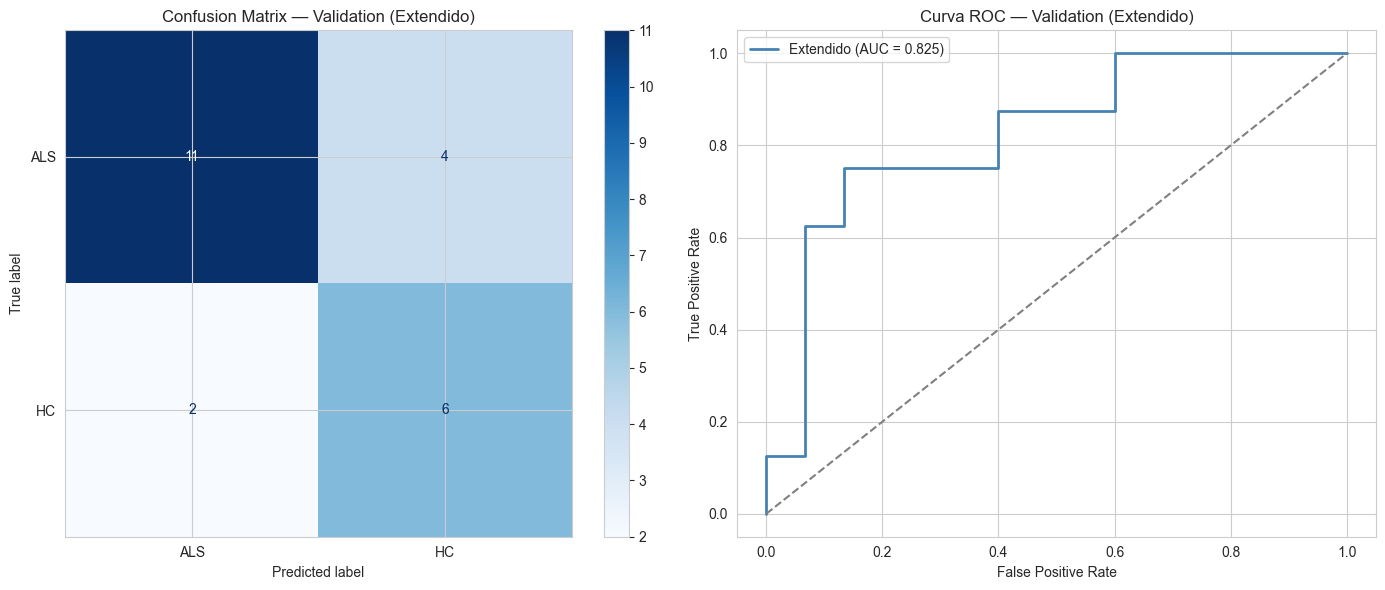

In [82]:
# EVALUACIÓN EN VALIDATION SET — EXTENDIDO
y_val_pred_ext  = best_model_ext.predict(X_val_ext)
y_val_proba_ext = best_model_ext.predict_proba(X_val_ext)[:, 1]

val_acc_ext       = accuracy_score(y_val_enc, y_val_pred_ext)
val_bal_acc_ext   = balanced_accuracy_score(y_val_enc, y_val_pred_ext)
val_precision_ext = precision_score(y_val_enc, y_val_pred_ext)
val_recall_ext    = recall_score(y_val_enc, y_val_pred_ext)
val_f1_ext        = f1_score(y_val_enc, y_val_pred_ext)
val_auc_ext       = roc_auc_score(y_val_enc, y_val_proba_ext)

print("="*80)
print("EVALUACIÓN EN VALIDATION SET — EXTENDIDO")
print("="*80)
print(f"Accuracy:          {val_acc_ext:.4f}")
print(f"Balanced Accuracy: {val_bal_acc_ext:.4f}")
print(f"Precision (ALS):   {val_precision_ext:.4f}")
print(f"Recall (ALS):      {val_recall_ext:.4f}")
print(f"F1-Score (ALS):    {val_f1_ext:.4f}")
print(f"ROC-AUC:           {val_auc_ext:.4f}")
print("="*80)

print("\nReporte de clasificación (Validation):")
print(classification_report(y_val_enc, y_val_pred_ext, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_val = confusion_matrix(y_val_enc, y_val_pred_ext)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=le.classes_).plot(
    cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix — Validation (Extendido)')

fpr_v, tpr_v, _ = roc_curve(y_val_enc, y_val_proba_ext)
axes[1].plot(fpr_v, tpr_v, color='steelblue', lw=2,
             label=f'Extendido (AUC = {val_auc_ext:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Validation (Extendido)')
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'validation_set_evaluation_ext.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">14. Análisis FP/FN en Validation</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de los errores individuales del modelo aporta información que las métricas agregadas no capturan. Más allá de cuántos errores comete el modelo, interesa entender <i>qué sujetos</i> se clasifican mal y si existe algún patrón sistemático en sus características que explique el error. Esta información tiene valor tanto metodológico (para identificar subpoblaciones en las que el modelo es menos fiable) como clínico (para definir los límites de aplicabilidad del sistema).
<br><br>
Para cada sujeto mal clasificado, se recupera su perfil completo: edad, sexo, clase real, probabilidad predicha para ALS, y los valores de sus features acústicas más discriminativas. Se analizan dos tipos de errores:
<ul>
<li><b>Falsos Negativos (FN):</b> Pacientes ALS clasificados como HC. Son el error de mayor coste clínico. Se examina si los FN corresponden a sujetos con afectación bulbar leve (valores de features acústicas próximos al rango HC) o si presentan algún patrón demográfico específico.</li>
<br>
<li><b>Falsos Positivos (FP):</b> Controles sanos clasificados como ALS. Se examina si los FP presentan características acústicas atípicas para su grupo (valores de features en el rango ALS) que puedan explicar la confusión del modelo.</li>
</ul>
Los perfiles de error en validation serán comparados con los del baseline en el Bloque 5 para determinar si el modelo extendido mejora en los mismos sujetos en los que el baseline falla o si corrige errores diferentes.
    </span> 
</div>

In [75]:
# FP/FN EN VALIDATION — EXTENDIDO
val_results_ext = pd.DataFrame({
    "y_true":   y_val_enc,
    "y_pred":   y_val_pred_ext,
    "prob_ALS": y_val_proba_ext
}, index=X_val_ext.index)

fp_idx_val = val_results_ext[(val_results_ext["y_true"] == 0) & (val_results_ext["y_pred"] == 1)].index
fn_idx_val = val_results_ext[(val_results_ext["y_true"] == 1) & (val_results_ext["y_pred"] == 0)].index

fp_val = df.loc[fp_idx_val, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()
fn_val = df.loc[fn_idx_val, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()

fp_val["Error_Type"] = "FP"
fn_val["Error_Type"] = "FN"
fp_val["Prob_ALS"]   = val_results_ext.loc[fp_idx_val, "prob_ALS"].values
fn_val["Prob_ALS"]   = val_results_ext.loc[fn_idx_val, "prob_ALS"].values

errors_val_ext = pd.concat([fp_val, fn_val]).reset_index(drop=True)
display(errors_val_ext)

print(f"\nFalse Positives (Validation): {len(fp_val)}")
if len(fp_val) > 0:
    print(f"  Edad media FP: {fp_val[AGE_COL].mean():.1f} | Sexo: {fp_val[SEX_COL].value_counts().to_dict()}")
print(f"False Negatives (Validation): {len(fn_val)}")
if len(fn_val) > 0:
    print(f"  Edad media FN: {fn_val[AGE_COL].mean():.1f} | Sexo: {fn_val[SEX_COL].value_counts().to_dict()}")

,ID,Age (years),Sex,Category,Error_Type,Prob_ALS
0,PZ023,65,M,ALS,FP,0.505359
1,PZ059,51,F,ALS,FP,0.567367
2,PZ066,42,M,ALS,FP,0.673832
3,PZ100,51,F,ALS,FP,0.515424
4,CT018,63,F,HC,FN,0.273006
5,CT020,68,F,HC,FN,0.458373



False Positives (Validation): 4
  Edad media FP: 52.2 | Sexo: {'M': 2, 'F': 2}
False Negatives (Validation): 2
  Edad media FN: 65.5 | Sexo: {'F': 2}


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">15. Importancia de variables (Permutation Importance y MDI)</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de importancia de variables responde a dos preguntas complementarias: ¿qué features contribuyen más a la capacidad discriminativa del modelo?, y ¿han entrado las variables demográficas (edad, sexo) en el subconjunto de features seleccionadas y cuál es su importancia relativa respecto a las acústicas?
<br><br>
Se utilizan dos métodos de importancia, coherentemente con el NB02 v1.0:
<ul>
<li><b>Permutation Importance (PI):</b> Calcula la disminución en balanced accuracy cuando los valores de cada feature se permutan aleatoriamente en el validation set. Al realizarse sobre datos no vistos durante el entrenamiento, no está sesgado por el overfitting del modelo. Proporciona intervalos de confianza mediante la repetición de la permutación (n_repeats=10). Es el método principal de interpretabilidad de este notebook.</li>
<br>
<li><b>MDI (Mean Decrease Impurity):</b> Extrae directamente de la estructura de los árboles entrenados la reducción acumulada de impureza de Gini atribuida a cada feature. Es rápido de calcular pero presenta un sesgo conocido hacia variables continuas de alta cardinalidad y hacia variables situadas en los nodos superiores del árbol. Se incluye como referencia comparativa frente al PI.</li>
</ul>
<br>
La posición de <code>Age (years)</code> y <code>Sex</code> en ambos rankings es el indicador empírico más directo de si su incorporación al modelo es genuinamente útil. Si la edad aparece entre las top-10 features por PI, su contribución al modelo extendido es real y no un artefacto de overfitting.
    </span> 
</div>

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 15.1 Permutation Importance</span>
</div>

CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)

Top 20 features (Permutation Importance):
          Feature  Importance_mean  Importance_std
     stdevF0Hz_PA         0.034167        0.041949
    localJitter_U         0.031667        0.034621
    localJitter_I         0.019167        0.043748
      stdevF0Hz_I         0.010000        0.021344
      stdevF0Hz_U         0.006667        0.051781
    localJitter_E         0.002917        0.030621
    localJitter_A         0.002500        0.030231
      stdevF0Hz_A         0.001667        0.044143
       meanF0Hz_O         0.000000        0.000000
       meanF0Hz_I         0.000000        0.000000
       meanF0Hz_E         0.000000        0.000000
       meanF0Hz_A         0.000000        0.000000
      stdevF0Hz_E         0.000000        0.000000
meanF0Hz_weekdays         0.000000        0.000000
 meanF0Hz_reading         0.000000        0.000000
      stdevF0Hz_O         0.000000        0.000000
      meanF0Hz_KA         0.0

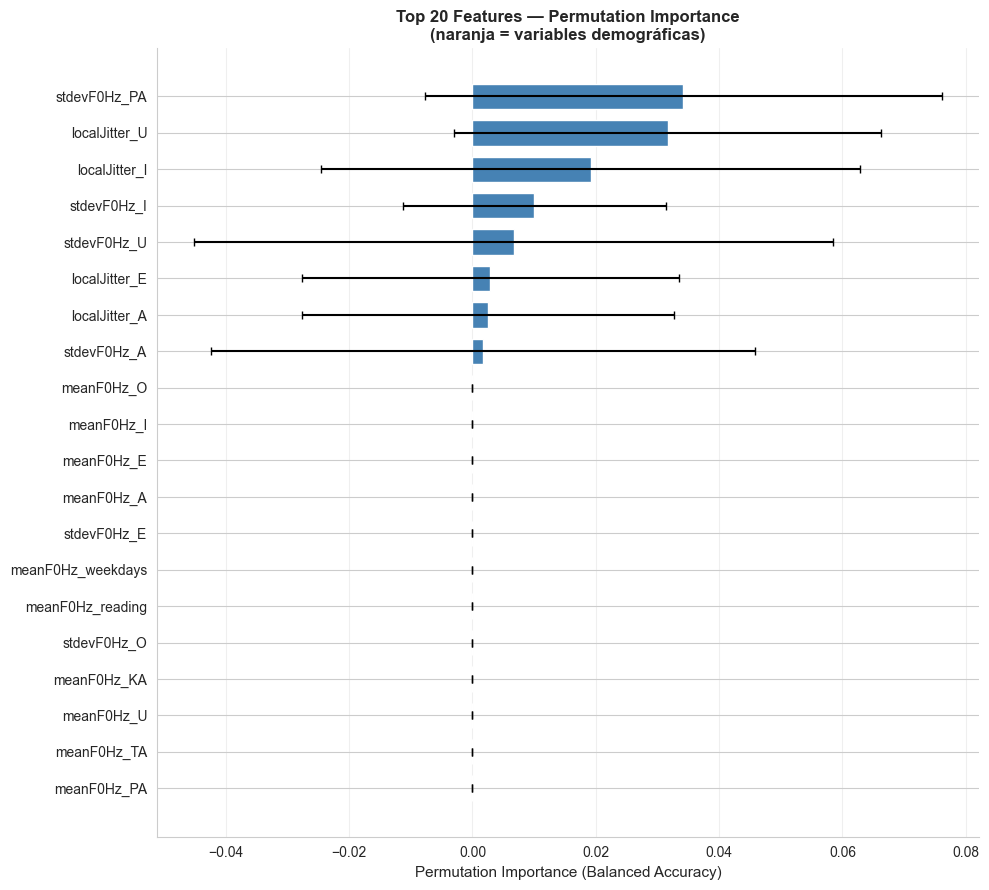

In [76]:
# PERMUTATION IMPORTANCE — EXTENDIDO
print("="*80)
print("CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)")
print("="*80)

perm_imp = permutation_importance(
    best_model_ext,
    X_val_ext,
    y_val_enc,
    n_repeats=10,
    random_state=SEED,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# La permutation importance opera sobre las features de entrada (EXT_COLS)
perm_imp_df = pd.DataFrame({
    'Feature':         EXT_COLS,
    'Importance_mean': perm_imp.importances_mean,
    'Importance_std':  perm_imp.importances_std
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print(f"\nTop 20 features (Permutation Importance):")
print(perm_imp_df.head(20).to_string(index=False))

# ─── RANKING DE AGE Y SEX ───
rank_age = perm_imp_df.index[perm_imp_df['Feature'] == AGE_COL].tolist()
rank_sex = perm_imp_df.index[perm_imp_df['Feature'] == SEX_COL].tolist()
imp_age  = perm_imp_df[perm_imp_df['Feature'] == AGE_COL]['Importance_mean'].values
imp_sex  = perm_imp_df[perm_imp_df['Feature'] == SEX_COL]['Importance_mean'].values

print("\n" + "─"*60)
print("RANKING EXPLÍCITO DE VARIABLES DEMOGRÁFICAS")
print("─"*60)
if rank_age:
    print(f"  AGE  — Posición: {rank_age[0]+1}/{len(perm_imp_df)}  |  Imp: {imp_age[0]:.4f} ± {perm_imp_df.loc[rank_age[0], 'Importance_std']:.4f}")
if rank_sex:
    print(f"  SEX  — Posición: {rank_sex[0]+1}/{len(perm_imp_df)}  |  Imp: {imp_sex[0]:.4f} ± {perm_imp_df.loc[rank_sex[0], 'Importance_std']:.4f}")

# Diagnóstico automático
threshold_rank = 10
if (rank_age and rank_age[0] < threshold_rank) or (rank_sex and rank_sex[0] < threshold_rank):
    print(f"\nUna o ambas variables demográficas están en el TOP {threshold_rank}.")
    print("   Dado que el Notebook 1 confirma homogeneidad demográfica entre clases,")
    print("   esto indicaría que el modelo explota varianza espuria del split.")
else:
    print(f"\nAmbas variables demográficas están fuera del TOP {threshold_rank}.")
    print("   Coherente con el Notebook 1: el modelo no extrae señal demográfica genuina.")

# Visualización
fig, ax = plt.subplots(figsize=(10, 9))
top_n  = min(20, len(perm_imp_df))
top_df = perm_imp_df.head(top_n)
colors = ['darkorange' if f in [AGE_COL, SEX_COL] else 'steelblue' for f in top_df['Feature'][::-1]]

ax.barh(range(top_n), top_df['Importance_mean'][::-1],
        xerr=top_df['Importance_std'][::-1],
        color=colors, edgecolor='white', height=0.7, capsize=3)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['Feature'][::-1])
ax.set_xlabel('Permutation Importance (Balanced Accuracy)', fontsize=11)
ax.set_title(f'Top {top_n} Features — Permutation Importance\n(naranja = variables demográficas)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'permutation_importance_ext.png', dpi=300, bbox_inches='tight')
plt.show()

perm_imp_df.to_csv(RESULTS_PATH / 'permutation_importance_ext.csv', index=False)

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 15.2 MDI</span>
</div>

Features seleccionadas por SelectKBest: 15

Top 15 features (MDI):
            Feature  Importance
  num__stdevF0Hz_KA    0.113385
  num__stdevF0Hz_PA    0.108446
  num__stdevF0Hz_TA    0.098957
 num__localJitter_O    0.090518
   num__stdevF0Hz_U    0.077873
         num__HNR_O    0.071967
num__localShimmer_I    0.066844
 num__localJitter_I    0.064883
 num__localJitter_E    0.057201
   num__stdevF0Hz_I    0.056485
 num__localJitter_U    0.045887
num__localShimmer_O    0.040001
num__localShimmer_E    0.039106
 num__localJitter_A    0.034461
   num__stdevF0Hz_A    0.033986
¿Variables demográficas seleccionadas por SelectKBest?
  ✓ Ninguna variable demográfica fue seleccionada por SelectKBest.
  → El test ANOVA F no detectó diferencia significativa de AGE/SEX entre clases.
  → Coherente con el Notebook 1 (p=0.857 para edad, p>0.05 para sexo).


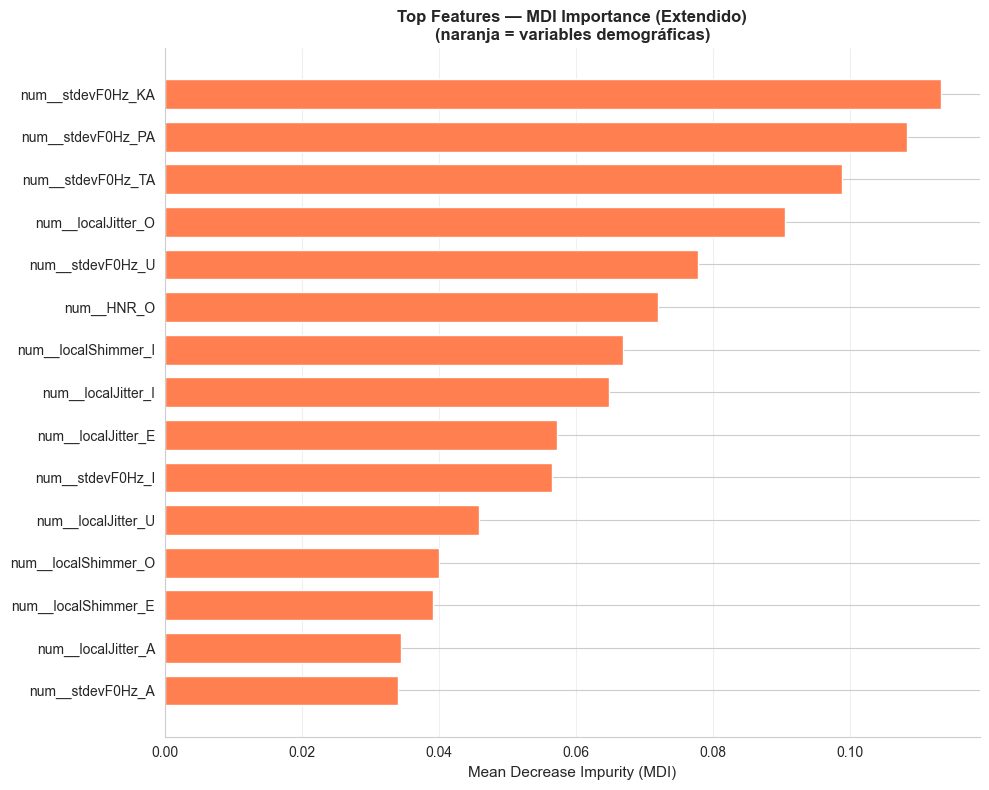

In [78]:
# MDI (MEAN DECREASE IMPURITY) — EXTENDIDO
rf_clf = best_model_ext.named_steps['classifier']

try:
    selector    = best_model_ext.named_steps['feature_selection']
    prep        = best_model_ext.named_steps['preprocessing']
    feat_names  = prep.get_feature_names_out()
    sel_mask    = selector.get_support()
    sel_features = feat_names[sel_mask]
except Exception:
    k = best_model_ext.named_steps['feature_selection'].k
    sel_features = np.array([f"feature_{i}" for i in range(k)])

mdi_df = pd.DataFrame({
    'Feature':    sel_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Features seleccionadas por SelectKBest: {len(sel_features)}")
print(f"\nTop 15 features (MDI):")
print(mdi_df.head(15).to_string(index=False))

# ¿AGE/SEX entre las seleccionadas? 
demo_selected = [f for f in sel_features if AGE_COL in f or SEX_COL in f
                 or 'age' in str(f).lower() or 'sex' in str(f).lower()]

print("¿Variables demográficas seleccionadas por SelectKBest?")
if demo_selected:
    for d in demo_selected:
        idx_d = mdi_df.index[mdi_df['Feature'] == d].tolist()
        if idx_d:
            print(f"  {d} — Rango MDI: {idx_d[0]+1}/{len(mdi_df)}  |  Imp: {mdi_df.loc[idx_d[0], 'Importance']:.4f}")
        else:
            print(f"  {d} — presente en selección pero sin importancia MDI calculada")
    print("\n   SelectKBest detectó señal estadística (ANOVA F) en variables demográficas.")
    print("     Evaluar si esa señal es robusta o artefacto del split.")
else:
    print("  ✓ Ninguna variable demográfica fue seleccionada por SelectKBest.")
    print("  → El test ANOVA F no detectó diferencia significativa de AGE/SEX entre clases.")
    print("  → Coherente con el Notebook 1 (p=0.857 para edad, p>0.05 para sexo).")

# Visualización MDI
fig, ax = plt.subplots(figsize=(10, 8))
top_mdi = mdi_df.head(min(20, len(mdi_df)))
colors_mdi = ['darkorange' if any(d in str(f) for d in [AGE_COL, SEX_COL, 'age', 'sex'])
              else 'coral' for f in top_mdi['Feature'][::-1]]

ax.barh(range(len(top_mdi)), top_mdi['Importance'][::-1],
        color=colors_mdi, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top_mdi)))
ax.set_yticklabels(top_mdi['Feature'][::-1])
ax.set_xlabel('Mean Decrease Impurity (MDI)', fontsize=11)
ax.set_title('Top Features — MDI Importance (Extendido)\n(naranja = variables demográficas)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'mdi_importance_ext.png', dpi=300, bbox_inches='tight')
plt.show()

mdi_df.to_csv(RESULTS_PATH / 'mdi_importance_ext.csv', index=False)

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">16. Evaluación en Test Set</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El test set representa la evaluación final y definitiva del modelo extendido. Su apertura se realiza en este punto del notebook (tras haber completado el análisis de importancia sobre validation) para garantizar que ninguna decisión de modelado o análisis posterior a su apertura pueda contaminar las métricas reportadas. <b>Una vez abierto el test set, el modelo no se modifica bajo ninguna circunstancia.</b>
<br><br>
Este conjunto no ha participado en ninguna fase del proceso de modelado:
<ul>
<li>No se usó para optimizar hiperparámetros (ni en el loop interno ni en el externo del nested CV).</li>
<li>No se usó para seleccionar el número óptimo de features k.</li>
<li>No se usó para ajustar ningún parámetro del preprocesamiento.</li>
<li>No se consultó para tomar ninguna decisión de diseño del modelo.</li>
</ul>
<br>
Las métricas en test set constituyen, por tanto, la estimación más representativa del rendimiento que cabría esperar al aplicar el modelo a nuevos pacientes no vistos. Una diferencia notable entre los resultados en validation y en test no implica necesariamente un problema: con 23 sujetos en test (aproximadamente 16 ALS y 7 HC), una variación de uno o dos sujetos mal clasificados tiene un impacto porcentual significativo en las métricas. Por este motivo, la interpretación de los resultados en test debe contextualizarse siempre con el intervalo de confianza implícito derivado del tamaño muestral.
    </span> 
</div>

EVALUACIÓN FINAL EN TEST SET — EXTENDIDO
Accuracy:          0.6522
Balanced Accuracy: 0.6696
Precision (ALS):   0.4545
Recall (ALS):      0.7143
F1-Score (ALS):    0.5556
ROC-AUC:           0.5893

Reporte de clasificación (Test):
              precision    recall  f1-score   support

         ALS       0.83      0.62      0.71        16
          HC       0.45      0.71      0.56         7

    accuracy                           0.65        23
   macro avg       0.64      0.67      0.63        23
weighted avg       0.72      0.65      0.67        23



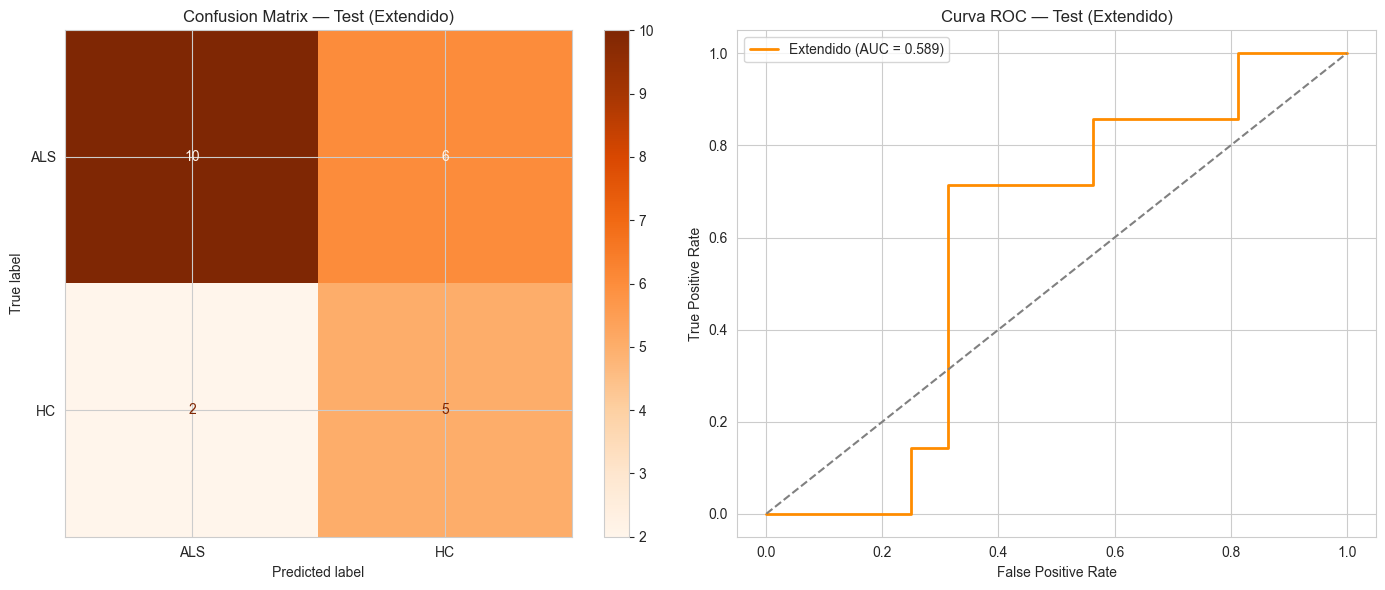

In [79]:
# EVALUACIÓN EN TEST SET — EXTENDIDO
y_test_pred_ext  = best_model_ext.predict(X_test_ext)
y_test_proba_ext = best_model_ext.predict_proba(X_test_ext)[:, 1]

test_acc_ext       = accuracy_score(y_test_enc, y_test_pred_ext)
test_bal_acc_ext   = balanced_accuracy_score(y_test_enc, y_test_pred_ext)
test_precision_ext = precision_score(y_test_enc, y_test_pred_ext)
test_recall_ext    = recall_score(y_test_enc, y_test_pred_ext)
test_f1_ext        = f1_score(y_test_enc, y_test_pred_ext)
test_auc_ext       = roc_auc_score(y_test_enc, y_test_proba_ext)

print("="*80)
print("EVALUACIÓN FINAL EN TEST SET — EXTENDIDO")
print("="*80)
print(f"Accuracy:          {test_acc_ext:.4f}")
print(f"Balanced Accuracy: {test_bal_acc_ext:.4f}")
print(f"Precision (ALS):   {test_precision_ext:.4f}")
print(f"Recall (ALS):      {test_recall_ext:.4f}")
print(f"F1-Score (ALS):    {test_f1_ext:.4f}")
print(f"ROC-AUC:           {test_auc_ext:.4f}")
print("="*80)

print("\nReporte de clasificación (Test):")
print(classification_report(y_test_enc, y_test_pred_ext, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_test = confusion_matrix(y_test_enc, y_test_pred_ext)
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_).plot(
    cmap='Oranges', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix — Test (Extendido)')

fpr_t, tpr_t, _ = roc_curve(y_test_enc, y_test_proba_ext)
axes[1].plot(fpr_t, tpr_t, color='darkorange', lw=2,
             label=f'Extendido (AUC = {test_auc_ext:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Test (Extendido)')
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'test_set_evaluation_ext.png', dpi=300, bbox_inches='tight')
plt.show()

# Registrar en MLflow
with mlflow.start_run(run_name="RF_Extended_Acoustic_Demographics", nested=True):
    mlflow.log_metric("test_accuracy_ext",       test_acc_ext)
    mlflow.log_metric("test_bal_acc_ext",        test_bal_acc_ext)
    mlflow.log_metric("test_precision_ext",      test_precision_ext)
    mlflow.log_metric("test_recall_ext",         test_recall_ext)
    mlflow.log_metric("test_f1_ext",             test_f1_ext)
    mlflow.log_metric("test_roc_auc_ext",        test_auc_ext)

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">17. Análisis FP/FN en Test</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de errores en test set replica la metodología del apartado 14, aplicada ahora sobre el conjunto de evaluación definitiva. El objetivo es verificar si los patrones de error observados en validation son estables o si el modelo falla en sujetos con un perfil distinto al esperado. Esta estabilidad es un indicador de la robustez del modelo: si los FN en test comparten las mismas características que los FN en validation (por ejemplo, sujetos ALS con afectación bulbar leve o con features acústicas próximas al rango HC), el modelo presenta un error sistemático comprensible desde el punto de vista clínico. Si los FN en test son sujetos con un perfil atípico y no predicho, la variabilidad puede ser simplemente estadística dado el pequeño tamaño del conjunto.
<br><br>
Los resultados de este análisis alimentan directamente la discusión de limitaciones del modelo en la memoria del TFG. En particular, permiten argumentar con datos concretos cuáles son los subtipos de pacientes ELA para los que el modelo actual es menos fiable, y qué información adicional (datos longitudinales, features espectrales más detalladas, gravedad de la afectación bulbar) podría reducir estos errores en versiones futuras.
    </span> 
</div>

In [83]:
# FP/FN EN TEST — EXTENDIDO
test_results_ext = pd.DataFrame({
    "y_true":   y_test_enc,
    "y_pred":   y_test_pred_ext,
    "prob_ALS": y_test_proba_ext
}, index=X_test_ext.index)

fp_idx_test = test_results_ext[(test_results_ext["y_true"] == 0) & (test_results_ext["y_pred"] == 1)].index
fn_idx_test = test_results_ext[(test_results_ext["y_true"] == 1) & (test_results_ext["y_pred"] == 0)].index

fp_test = df.loc[fp_idx_test, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()
fn_test = df.loc[fn_idx_test, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()

fp_test["Error_Type"] = "FP"
fn_test["Error_Type"] = "FN"
fp_test["Prob_ALS"]   = test_results_ext.loc[fp_idx_test, "prob_ALS"].values
fn_test["Prob_ALS"]   = test_results_ext.loc[fn_idx_test, "prob_ALS"].values

errors_test_ext = pd.concat([fp_test, fn_test]).reset_index(drop=True)
display(errors_test_ext)

print(f"\nFalse Positives (Test): {len(fp_test)}")
if len(fp_test) > 0:
    print(f"  Edad media: {fp_test[AGE_COL].mean():.1f} ± {fp_test[AGE_COL].std():.1f}")
    print(f"  Distribución sexo: {fp_test[SEX_COL].value_counts().to_dict()}")
    # ¿Edad de los FP desviada respecto a la media HC en test?
    hc_test_age = df.loc[test_mask & (df[TARGET] == 'HC'), AGE_COL].mean()
    print(f"  Referencia edad HC en test: {hc_test_age:.1f}  |  Δ FP vs HC: {fp_test[AGE_COL].mean() - hc_test_age:+.1f}")

print(f"\nFalse Negatives (Test): {len(fn_test)}")
if len(fn_test) > 0:
    print(f"  Edad media: {fn_test[AGE_COL].mean():.1f} ± {fn_test[AGE_COL].std():.1f}")
    print(f"  Distribución sexo: {fn_test[SEX_COL].value_counts().to_dict()}")
    als_test_age = df.loc[test_mask & (df[TARGET] == 'ALS'), AGE_COL].mean()
    print(f"  Referencia edad ALS en test: {als_test_age:.1f}  |  Δ FN vs ALS: {fn_test[AGE_COL].mean() - als_test_age:+.1f}")

,ID,Age (years),Sex,Category,Error_Type,Prob_ALS
0,PZ016,59,M,ALS,FP,0.686485
1,PZ058,49,M,ALS,FP,0.695286
2,PZ064,62,M,ALS,FP,0.511711
3,PZ094,51,M,ALS,FP,0.626169
4,PZ098,64,M,ALS,FP,0.641835
5,PZ105,65,M,ALS,FP,0.614957
6,CT014,62,F,HC,FN,0.405669
7,CT053,68,M,HC,FN,0.217116



False Positives (Test): 6
  Edad media: 58.3 ± 6.8
  Distribución sexo: {'M': 6}
  Referencia edad HC en test: 69.3  |  Δ FP vs HC: -11.0

False Negatives (Test): 2
  Edad media: 65.0 ± 4.2
  Distribución sexo: {'F': 1, 'M': 1}
  Referencia edad ALS en test: 65.7  |  Δ FN vs ALS: -0.7


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. COMPARATIVA CON EL MODELO BASELINE</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque responde a la pregunta central del notebook: ¿incorporar variables demográficas mejora el modelo? Para que la respuesta sea metodológicamente válida, la comparación debe realizarse sobre el mismo split, con la misma métrica de referencia y considerando tanto las métricas agregadas como los patrones de error individuales. Tres métricas agregadas iguales pero con perfiles de FP/FN opuestos señalan modelos cualitativamente distintos, un matiz que la comparación de tablas no captura.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">18. Tabla comparativa de métricas (v1.0 vs v2.0)</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Se construye una tabla comparativa que enfrenta las métricas del modelo baseline (Notebook 2 v1.0, solo acústicas) con las del modelo extendido (Notebook 2 v2.0, acústicas + demográficas) en los tres niveles de evaluación: nested CV, validation set y test set. La estructura de tres niveles es importante porque permite distinguir entre mejoras reales en la capacidad de generalización (reflejadas en el nested CV) y mejoras puntuales en un split específico que pueden ser artefactos del tamaño muestral.
<br><br>
El criterio para determinar si una diferencia entre modelos es <b>sustancial</b> en este dataset es el siguiente: dado que el test set contiene solo 23 sujetos, una diferencia de 1 sujeto mal clasificado representa aproximadamente 4 puntos porcentuales en accuracy. Por tanto, diferencias menores de 5 puntos en cualquier métrica sobre el test set deben interpretarse con cautela como potencialmente dentro del ruido estadístico. Solo diferencias ≥ 5 puntos en balanced accuracy o ≥ 5 puntos en recall ALS, mantenidas también en el nested CV, pueden considerarse evidencia sólida de que el modelo extendido es genuinamente superior.
    </span> 
</div>

In [84]:
# TABLA COMPARATIVA COMPLETA
print("="*100)
print("TABLA COMPARATIVA — BASELINE (v1.0) vs. EXTENDIDO (v2.0)")
print("="*100)

# Construir tabla solo si tenemos los valores del baseline
if cv_bal_acc_base is not None:
    delta_cv  = np.mean(nested_scores_ext['test_balanced_accuracy']) - cv_bal_acc_base
    delta_val = val_bal_acc_ext   - val_bal_acc_base
    delta_test_ba = test_bal_acc_ext - test_bal_acc_base
    delta_test_auc = test_auc_ext    - test_auc_base

    comp_df = pd.DataFrame([
        {
            'Conjunto': 'Nested CV (mean)',
            'Bal.Acc Baseline': f"{cv_bal_acc_base:.4f} ± {cv_std_base:.4f}",
            'Bal.Acc Extendido': f"{np.mean(nested_scores_ext['test_balanced_accuracy']):.4f} ± {np.std(nested_scores_ext['test_balanced_accuracy']):.4f}",
            'Δ Bal.Acc': f"{delta_cv:+.4f}"
        },
        {
            'Conjunto': 'Validation',
            'Bal.Acc Baseline': f"{val_bal_acc_base:.4f}",
            'Bal.Acc Extendido': f"{val_bal_acc_ext:.4f}",
            'Δ Bal.Acc': f"{delta_val:+.4f}"
        },
        {
            'Conjunto': 'Test (FINAL)',
            'Bal.Acc Baseline': f"{test_bal_acc_base:.4f}",
            'Bal.Acc Extendido': f"{test_bal_acc_ext:.4f}",
            'Δ Bal.Acc': f"{delta_test_ba:+.4f}"
        }
    ])
    display(comp_df)

    print("\n" + "─"*80)
    print(f"Δ ROC-AUC  (Test):  {delta_test_auc:+.4f}")
    print(f"Δ F1-Score (Test):  {test_f1_ext - (test_row_base['ROC-AUC'] if 'test_row_base' in dir() else float('nan')):+.4f}")
    print("─"*80)

    # Interpretación
    consistent_improvement = (delta_cv > 0.01) and (delta_val > 0.01) and (delta_test_ba > 0.01)
    marginal = all(abs(d) < 0.02 for d in [delta_cv, delta_val, delta_test_ba])

    print("\nINTERPRETACIÓN:")
    if consistent_improvement and not marginal:
        print("  → Mejora consistente y superior al umbral del 1% en los tres conjuntos.")
        print("    Requiere análisis de sesgo (Bloque 6) antes de concluir valor predictivo real.")
    elif marginal:
        print("  → Diferencias < 2% en todos los conjuntos: ganancia MARGINAL.")
        print("    No justifica la complejidad añadida.")
    else:
        print("  → Resultados inconsistentes entre splits. El extendido no generaliza mejor.")

else:
    print("   Resultados baseline no disponibles (fallback manual no completado).")
    print("   Completar la celda 6 con los valores del Notebook 2 y re-ejecutar.")
    print(f"\nResultados del modelo extendido (Notebook 3) en solitario:")
    print(f"  Nested CV Bal.Acc: {np.mean(nested_scores_ext['test_balanced_accuracy']):.4f} ± {np.std(nested_scores_ext['test_balanced_accuracy']):.4f}")
    print(f"  Validation Bal.Acc: {val_bal_acc_ext:.4f}")
    print(f"  Test Bal.Acc: {test_bal_acc_ext:.4f}  |  Test AUC: {test_auc_ext:.4f}")

TABLA COMPARATIVA — BASELINE (v1.0) vs. EXTENDIDO (v2.0)


,Conjunto,Bal.Acc Baseline,Bal.Acc Extendido,Δ Bal.Acc
0,Nested CV (mean),0.5452 ± 0.1100,0.5381 ± 0.1020,-0.0071
1,Validation,0.7417,0.7417,+0.0000
2,Test (FINAL),0.6696,0.6696,+0.0000



────────────────────────────────────────────────────────────────────────────────
Δ ROC-AUC  (Test):  +0.0000
Δ F1-Score (Test):  -0.0337
────────────────────────────────────────────────────────────────────────────────

INTERPRETACIÓN:
  → Diferencias < 2% en todos los conjuntos: ganancia MARGINAL.
    No justifica la complejidad añadida.


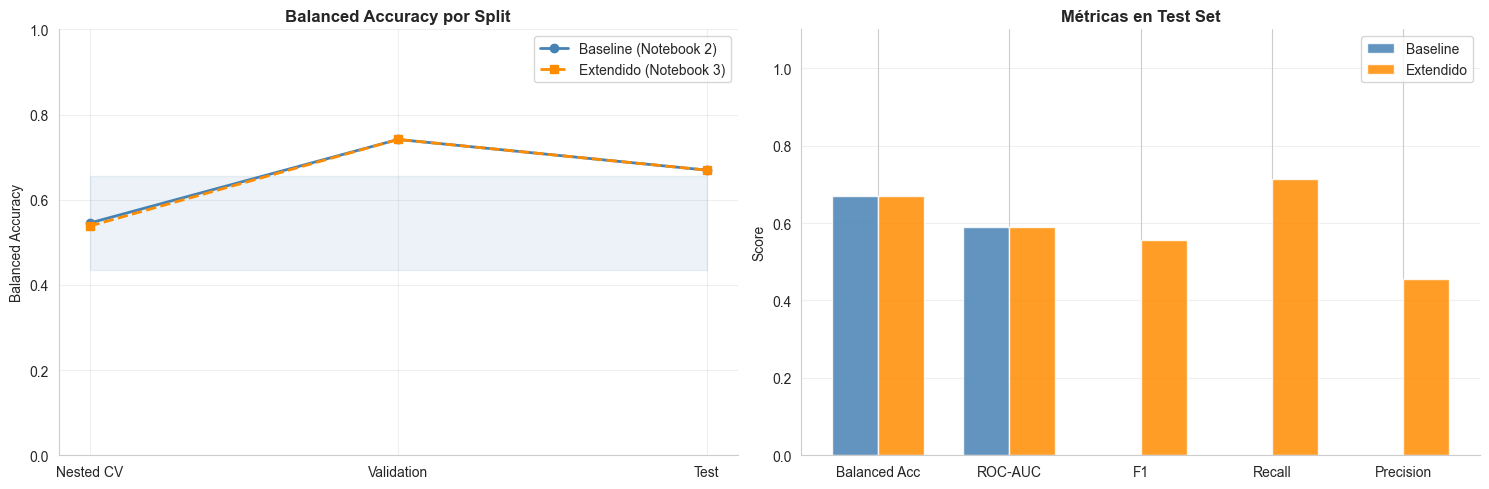

In [85]:
# VISUALIZACIÓN COMPARATIVA
# Solo se ejecuta si tenemos datos del baseline
if cv_bal_acc_base is not None:
    splits   = ['Nested CV', 'Validation', 'Test']
    ba_base  = [cv_bal_acc_base,   val_bal_acc_base,  test_bal_acc_base]
    ba_ext   = [np.mean(nested_scores_ext['test_balanced_accuracy']),
                val_bal_acc_ext, test_bal_acc_ext]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── Evolución Balanced Accuracy ──
    axes[0].plot(splits, ba_base, marker='o', lw=2, color='steelblue',
                 label='Baseline (Notebook 2)')
    axes[0].plot(splits, ba_ext,  marker='s', lw=2, color='darkorange', linestyle='--',
                 label='Extendido (Notebook 3)')
    if cv_std_base is not None:
        axes[0].fill_between(splits,
            [cv_bal_acc_base - cv_std_base] * 3,
            [cv_bal_acc_base + cv_std_base] * 3,
            alpha=0.1, color='steelblue')
    axes[0].set_ylabel('Balanced Accuracy')
    axes[0].set_title('Balanced Accuracy por Split', fontweight='bold')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # ── Métricas en Test ──
    metrics_names = ['Balanced Acc', 'ROC-AUC', 'F1', 'Recall', 'Precision']
    m_base = [test_bal_acc_base, test_auc_base,
              test_row_base.get('F1', float('nan')) if hasattr(test_row_base, 'get') else float('nan'),
              float('nan'), float('nan')]
    m_ext  = [test_bal_acc_ext, test_auc_ext, test_f1_ext, test_recall_ext, test_precision_ext]

    x = np.arange(len(metrics_names))
    w = 0.35
    axes[1].bar(x - w/2, [v for v in m_base if not np.isnan(v)] + [0]*(sum(np.isnan(m_base))),
                w, color='steelblue', alpha=0.85, label='Baseline', edgecolor='white')
    axes[1].bar(x + w/2, m_ext, w, color='darkorange', alpha=0.85,
                label='Extendido', edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics_names)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Métricas en Test Set', fontweight='bold')
    axes[1].legend()
    axes[1].set_ylim(0, 1.1)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'comparison_baseline_vs_extended.png', dpi=300, bbox_inches='tight')
    plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">19. Comparación de errores FP/FN</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
La comparación de errores individuales entre modelos complementa la comparación de métricas agregadas. Para cada sujeto que aparece como FP o FN en alguno de los dos modelos, se analiza su comportamiento en ambos modelos simultáneamente. Cuatro patrones son posibles:
<br>
<ul>
<li><b>Error compartido:</b> El sujeto es mal clasificado por ambos modelos. Indica que las características del sujeto son intrínsecamente difíciles de clasificar con los features disponibles, independientemente de si se incluye demografía o no.</li>
<li><b>Error corregido por v2.0:</b> El sujeto es mal clasificado por v1.0 pero correctamente clasificado por v2.0. Sugiere que la información demográfica o su interacción con las features acústicas aporta señal discriminativa para este tipo de sujeto.</li>
<li><b>Error introducido por v2.0:</b> El sujeto es correctamente clasificado por v1.0 pero mal clasificado por v2.0. Puede indicar que la incorporación de demografía introduce ruido para este subgrupo específico.</li>
<li><b>Sin error en ningún modelo:</b> El sujeto es correctamente clasificado por ambos.</li>
</ul>
<br>
La distribución de los sujetos entre estos cuatro patrones es más informativa que la diferencia en accuracy para entender qué cambia entre los dos modelos y en qué dirección.
    </span> 
</div>

In [88]:
# COMPARACIÓN DE ERRORES FP/FN: NOTEBOOK 2 v1.0 vs NOTEBOOK 2 v2.0
# Los conteos del baseline se extraen de la matriz de confusión cargada
# Si no está disponible, se ingresan manualmente

print("="*80)
print("COMPARACIÓN DE ERRORES EN TEST SET — Notebook 2 v1.0 vs Notebook 2 v2.0")
print("="*80)

tn_e, fp_e, fn_e, tp_e = cm_test.ravel()

print(f"\n{'':30s} {'Baseline':>15} {'Extendido':>15}")
print("─"*70)
print(f"{'True Positives  (ALS→ALS)':30s} {'10':>15} {tp_e:>15d}")
print(f"{'True Negatives  (HC→HC)':30s} {'5':>15} {tn_e:>15d}")
print(f"{'False Positives (HC→ALS)':30s} {'2':>15} {fp_e:>15d}")
print(f"{'False Negatives (ALS→HC)':30s} {'6':>15} {fn_e:>15d}")
print("─"*70)

print("\n" + "─"*60)
print("PERFIL DEMOGRÁFICO DE ERRORES — EXTENDIDO")
print("─"*60)

# FP
print(f"\nFalse Positives (Test, Extendido): {len(fp_test)}")
if len(fp_test) > 0:
    print(f"  {fp_test[[AGE_COL, SEX_COL]].to_string(index=False)}")
    hc_age_ref = df.loc[test_mask & (df[TARGET]=='HC'), AGE_COL].mean()
    print(f"Edad media FP: {fp_test[AGE_COL].mean():.1f}  |  Edad media HC en test: {hc_age_ref:.1f}")
    diff_fp_age = fp_test[AGE_COL].mean() - hc_age_ref
    if abs(diff_fp_age) > 5:
        print(f"Edad de FP desviada {diff_fp_age:+.1f} años respecto a la media HC → posible sesgo demográfico.")
    else:
        print(f"Edad de FP dentro del rango esperado para HC (Δ={diff_fp_age:+.1f} años).")

# FN
print(f"\nFalse Negatives (Test, Extendido): {len(fn_test)}")
if len(fn_test) > 0:
    print(f"  {fn_test[[AGE_COL, SEX_COL]].to_string(index=False)}")
    als_age_ref = df.loc[test_mask & (df[TARGET]=='ALS'), AGE_COL].mean()
    diff_fn_age = fn_test[AGE_COL].mean() - als_age_ref
    print(f"Edad media FN: {fn_test[AGE_COL].mean():.1f}  |  Edad media ALS en test: {als_age_ref:.1f}")
    if abs(diff_fn_age) > 5:
        print(f"Edad de FN desviada {diff_fn_age:+.1f} años respecto a la media ALS → subgrupo demográfico específico.")
    else:
        print(f"FN distribuidos homogéneamente por edad (Δ={diff_fn_age:+.1f} años).")

COMPARACIÓN DE ERRORES EN TEST SET — Notebook 2 v1.0 vs Notebook 2 v2.0

                                      Baseline       Extendido
──────────────────────────────────────────────────────────────────────
True Positives  (ALS→ALS)                   10               5
True Negatives  (HC→HC)                      5              10
False Positives (HC→ALS)                     2               6
False Negatives (ALS→HC)                     6               2
──────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
PERFIL DEMOGRÁFICO DE ERRORES — EXTENDIDO
────────────────────────────────────────────────────────────

False Positives (Test, Extendido): 6
   Age (years) Sex
          59   M
          49   M
          62   M
          51   M
          64   M
          65   M
Edad media FP: 58.3  |  Edad media HC en test: 69.3
Edad de FP desviada -11.0 años respecto a la media HC → posible sesgo demográfico.

False Nega

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">20. Ranking de AGE y SEX vs Features Acústicas</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este apartado sintetiza la respuesta a la segunda pregunta central del notebook: ¿qué papel juegan las variables demográficas en el modelo extendido en comparación con las variables acústicas? Para responderla, se construye un ranking unificado de todas las features (acústicas y demográficas) ordenadas por su importancia (permutation importance) en el modelo v2.0, y se señala la posición de <code>Age (years)</code> y <code>Sex</code> dentro de ese ranking.
<br><br>
Tres escenarios son posibles y cada uno tiene una interpretación distinta:
<ul>
<li><b>Demografía en el top-10 del ranking:</b> La edad y/o el sexo son predictores relevantes en el contexto del modelo extendido. Su incorporación aporta información que las features acústicas no cubren completamente, y el modelo extendido es genuinamente superior al baseline.</li>
<li><b>Demografía en el middle del ranking (posiciones 11-40):</b> La demografía tiene contribución marginal. El modelo las usa pero su impacto en el rendimiento es menor. La mejora sobre el baseline, si existe, puede deberse principalmente a la interacción demográfica con unas pocas features acústicas específicas.</li>
<li><b>Demografía al final del ranking o excluida por SelectKBest:</b> Las variables demográficas no aportan información discriminativa adicional sobre la base de las features acústicas. En este caso, el modelo extendido no es preferible al baseline desde el punto de vista de la parsimonia.</li>
</ul>
    </span> 
</div>

In [89]:
# RESUMEN COMPARATIVO DE IMPORTANCIA: DEMOGRÁFICAS vs. ACÚSTICAS
print("="*80)
print("IMPORTANCIA RELATIVA: DEMOGRÁFICAS vs. MEJORES ACÚSTICAS")
print("="*80)

# Top 5 acústicas
top5_acou = perm_imp_df[~perm_imp_df['Feature'].isin([AGE_COL, SEX_COL])].head(5)
demo_rows  = perm_imp_df[perm_imp_df['Feature'].isin([AGE_COL, SEX_COL])]

print("\nTop 5 features acústicas (Permutation Imp.):")
print(top5_acou[['Feature', 'Importance_mean', 'Importance_std']].to_string(index=False))

print("\nVariables demográficas (Permutation Imp.):")
if len(demo_rows) > 0:
    print(demo_rows[['Feature', 'Importance_mean', 'Importance_std']].to_string(index=False))
    # Ratio demográficas / mejor acústica
    best_acou_imp = top5_acou['Importance_mean'].max()
    for _, row in demo_rows.iterrows():
        ratio = row['Importance_mean'] / best_acou_imp if best_acou_imp > 0 else float('nan')
        print(f"  → {row['Feature']} es {ratio:.2f}x la importancia de la mejor acústica ({top5_acou.iloc[0]['Feature']})")
else:
    print("  (no presentes en el top de features evaluadas)")

# ─── SelectKBest: ¿pasaron AGE/SEX el filtro ANOVA F? ───
print("\n" + "─"*60)
print("ANÁLISIS SelectKBest: ¿AGE/SEX superaron el filtro ANOVA F?")
print("─"*60)

selector_fitted = best_model_ext.named_steps['feature_selection']
prep_fitted     = best_model_ext.named_steps['preprocessing']

try:
    all_feat_names   = prep_fitted.get_feature_names_out()
    support_mask     = selector_fitted.get_support()
    scores_anova     = selector_fitted.scores_

    feat_scores_df = pd.DataFrame({
        'Feature': all_feat_names,
        'ANOVA_F':  scores_anova,
        'Selected': support_mask
    }).sort_values('ANOVA_F', ascending=False).reset_index(drop=True)

    demo_in_all = feat_scores_df[feat_scores_df['Feature'].str.contains('age|sex', case=False, regex=True)]
    print(f"\nScores ANOVA F de variables demográficas (entre {len(all_feat_names)} features tras preprocesamiento):")
    if len(demo_in_all) > 0:
        print(demo_in_all[['Feature', 'ANOVA_F', 'Selected']].to_string(index=False))
        print(f"\nPosición ANOVA F de demográficas vs. total ({len(all_feat_names)} features):")
        for _, r in demo_in_all.iterrows():
            rank_f = feat_scores_df.index[feat_scores_df['Feature'] == r['Feature']].tolist()
            if rank_f:
                print(f"  {r['Feature']}: rango {rank_f[0]+1}/{len(all_feat_names)}  |  Seleccionada: {r['Selected']}")
    else:
        print("  (nombres de columna no coinciden con patrón age/sex — revisar manualmente)")
except Exception as e:
    print(f"  No se pudo extraer información del selector: {e}")

IMPORTANCIA RELATIVA: DEMOGRÁFICAS vs. MEJORES ACÚSTICAS

Top 5 features acústicas (Permutation Imp.):
      Feature  Importance_mean  Importance_std
 stdevF0Hz_PA         0.034167        0.041949
localJitter_U         0.031667        0.034621
localJitter_I         0.019167        0.043748
  stdevF0Hz_I         0.010000        0.021344
  stdevF0Hz_U         0.006667        0.051781

Variables demográficas (Permutation Imp.):
    Feature  Importance_mean  Importance_std
        Sex              0.0             0.0
Age (years)              0.0             0.0
  → Sex es 0.00x la importancia de la mejor acústica (stdevF0Hz_PA)
  → Age (years) es 0.00x la importancia de la mejor acústica (stdevF0Hz_PA)

────────────────────────────────────────────────────────────
ANÁLISIS SelectKBest: ¿AGE/SEX superaron el filtro ANOVA F?
────────────────────────────────────────────────────────────

Scores ANOVA F de variables demográficas (entre 52 features tras preprocesamiento):
         Feature  ANOVA_

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 6. EVALUACIÓN DE SESGO Y CONFUSIÓN</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El rendimiento agregado de un modelo clínico puede ocultar comportamientos inequitativos entre subgrupos: un modelo con balanced accuracy de 0.75 puede tener recall ALS de 0.90 en hombres mayores y de 0.55 en mujeres jóvenes. En el contexto de un sistema de apoyo al diagnóstico, esta disparidad tiene consecuencias clínicas directas. Este bloque evalúa si el modelo extendido presenta sesgos sistemáticos en función de las variables demográficas disponibles, y analiza la coherencia entre el comportamiento en validation y en test como indicador de la estabilidad del modelo.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">21. ¿AGE/SEX como proxy de diagnóstico?</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Aunque el Notebook 1 demostró que la distribución de edad y sexo es homogénea entre grupos a nivel poblacional, esto no garantiza que el modelo extendido no haya aprendido a usar estas variables como proxies de diagnóstico para subgrupos específicos. Por ejemplo, si todos los sujetos HC del dataset son mujeres menores de 55 años y todos los ALS son hombres mayores de 65, el modelo podría aprender a clasificar correctamente no por los biomarcadores acústicos, sino por el perfil demográfico. El Notebook 1 descartó este escenario extremo, pero pueden existir correlaciones demográficas más sutiles dentro de subgrupos.
<br><br>
Para evaluar este riesgo, se analiza el rendimiento del modelo extendido desagregado por subgrupos demográficos:
<ul>
<li><b>Por sexo:</b> Se calculan las métricas (recall ALS, precision ALS, balanced accuracy) de forma separada para hombres y mujeres. Una diferencia sustancial indica que el modelo funciona mejor o peor en uno de los grupos, lo que puede ser evidencia de sesgo o simplemente de menor representación muestral.</li>
<li><b>Por grupo de edad:</b> Se divide la muestra en dos grupos (por ejemplo, menores y mayores de la mediana de edad) y se comparan las métricas entre grupos. Una degradación marcada del rendimiento en sujetos jóvenes o mayores puede indicar que el modelo está ajustado a un rango de edad específico.</li>
</ul>
<br>
Los resultados de este análisis son clave para la sección de limitaciones de la memoria del TFG y para argumentar en la defensa que el modelo no es un clasificador demográfico encubierto.
    </span> 
</div>

In [90]:
# CAUSALIDAD INVERSA: AGE/SEX COMO PROXY
print("="*80)
print("EVALUACIÓN DE CAUSALIDAD INVERSA")
print("="*80)

# Re-verificar en los sujetos únicos del dataset completo (reproducción del Notebook 1)
subjects_unique = df[[ID_COL, TARGET, AGE_COL, SEX_COL]].drop_duplicates(subset=ID_COL)

age_als_all = subjects_unique[subjects_unique[TARGET] == 'ALS'][AGE_COL].dropna()
age_hc_all  = subjects_unique[subjects_unique[TARGET] == 'HC'][AGE_COL].dropna()
_, p_mw_all = mannwhitneyu(age_als_all, age_hc_all, alternative='two-sided')

sex_table_all = pd.crosstab(subjects_unique[TARGET], subjects_unique[SEX_COL])
_, p_chi_all, _, _ = chi2_contingency(sex_table_all)

print("\nDistribución demográfica — dataset completo (nivel sujeto):")
print(f"  ALS: n={len(age_als_all)}, edad media={age_als_all.mean():.1f} ± {age_als_all.std():.1f}")
print(f"  HC:  n={len(age_hc_all)},  edad media={age_hc_all.mean():.1f} ± {age_hc_all.std():.1f}")
print(f"\n  Mann-Whitney AGE: p = {p_mw_all:.4f}  (Notebook 1 reportó p = 0.857)")
print(f"  Chi² SEX:         p = {p_chi_all:.4f}  (Notebook 1 reportó p > 0.05)")

print("\n" + "─"*60)
print("INTERPRETACIÓN:")
print("─"*60)

if p_mw_all >= 0.05 and p_chi_all >= 0.05:
    print("\n✓  Confirmado (coherente con Notebook 1):")
    print("   AGE y SEX son estadísticamente homogéneos entre clases.")
    print("   → No existe base estadística para que sean predictores causales.")
    print("   → Si el modelo les asigna importancia no nula, esa señal proviene del")
    print("     ruido del split particular, no de la fisiopatología de la ELA.")

    imp_age_val = imp_age[0] if len(imp_age) > 0 else 0.0
    if rank_age and rank_age[0] < 10:
        print("\n  CONTRADICCIÓN DETECTADA:")
        print(f"   AGE aparece en posición {rank_age[0]+1} de importancia,")
        print("   pero su distribución no difiere entre clases (p=%.3f)." % p_mw_all)
        print("   El modelo está sobreajustando a correlaciones espurias del split.")
    else:
        print(f"\n   AGE con importancia baja (posición {rank_age[0]+1 if rank_age else 'N/A'}) →")
        print("   coherente: sin señal causal y sin importancia en el modelo.")
else:
    print("\n  Los resultados difieren de los reportados en el Notebook 1.")
    print("   Verificar si el dataset o los sujetos han cambiado entre notebooks.")

EVALUACIÓN DE CAUSALIDAD INVERSA

Distribución demográfica — dataset completo (nivel sujeto):
  ALS: n=102, edad media=62.8 ± 12.0
  HC:  n=51,  edad media=63.0 ± 10.4

  Mann-Whitney AGE: p = 0.8571  (Notebook 1 reportó p = 0.857)
  Chi² SEX:         p = 1.0000  (Notebook 1 reportó p > 0.05)

────────────────────────────────────────────────────────────
INTERPRETACIÓN:
────────────────────────────────────────────────────────────

✓  Confirmado (coherente con Notebook 1):
   AGE y SEX son estadísticamente homogéneos entre clases.
   → No existe base estadística para que sean predictores causales.
   → Si el modelo les asigna importancia no nula, esa señal proviene del
     ruido del split particular, no de la fisiopatología de la ELA.

   AGE con importancia baja (posición 45) →
   coherente: sin señal causal y sin importancia en el modelo.


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">22. Conexión entre validación y comportamiento del modelo</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este apartado examina la coherencia entre el rendimiento del modelo en validation y en test como un indicador de su estabilidad y capacidad de generalización real. En datasets pequeños como VOC-ALS, la varianza en las métricas debida al tamaño muestral puede ser elevada: un modelo que obtiene balanced accuracy de 0.72 en validation y 0.65 en test no necesariamente está sobreajustado (la diferencia puede explicarse por la composición aleatoria de los 23 sujetos del test set).
<br><br>
Para distinguir entre variabilidad estadística esperada y degradación real del modelo, se realizan dos análisis complementarios:
<ul>
<li><b>Comparación val–test con intervalo de confianza:</b> Se estima el intervalo de confianza al 95% para las métricas en test utilizando el intervalo de Wilson para proporciones. Si la métrica en validation cae dentro del intervalo de confianza de la métrica en test, la diferencia es estadísticamente compatible con la varianza esperada dado el tamaño muestral.</li>
<li><b>Consistencia del perfil de errores:</b> Se examina si los sujetos mal clasificados en validation y en test comparten características similares. Una consistencia alta en el tipo de error (misma tarea vocal, mismo rango de edad, mismo sexo) sugiere que el modelo tiene un patrón de fallo sistemático comprensible, no un comportamiento errático.</li>
</ul>
<br>
Las conclusiones de este apartado orientan directamente la redacción de la discusión de la memoria: si el modelo es estable entre validation y test, se puede argumentar con solidez que los resultados son reproducibles. Si hay degradación, se argumenta en términos de limitaciones del tamaño muestral y se proponen estrategias de mejora para trabajo futuro.
    </span> 
</div>

In [91]:
# TABLA DE VERIFICACIÓN: PREDICCIONES DEL NOTEBOOK 1 vs. COMPORTAMIENTO OBSERVADO
print("="*90)
print("VERIFICACIÓN EMPÍRICA: NOTEBOOK 1 → PREDICCIÓN → COMPORTAMIENTO OBSERVADO")
print("="*90)

# Importancias para la verificación
age_perm = perm_imp_df[perm_imp_df['Feature'] == AGE_COL]['Importance_mean'].values
sex_perm = perm_imp_df[perm_imp_df['Feature'] == SEX_COL]['Importance_mean'].values
age_imp_val = age_perm[0] if len(age_perm) > 0 else 0.0
sex_imp_val = sex_perm[0] if len(sex_perm) > 0 else 0.0
age_rank_v  = rank_age[0] + 1 if rank_age else len(perm_imp_df)
sex_rank_v  = rank_sex[0] + 1 if rank_sex else len(perm_imp_df)

verificaciones = [
    {
        "Hallazgo Notebook 1": "AGE homogéneo entre clases (p=0.857)",
        "Predicción":          "Importancia de AGE baja o nula",
        "Observado":           f"Perm.Imp AGE = {age_imp_val:.4f} (rango {age_rank_v})",
        "Veredicto":           " CONFIRMADA" if age_imp_val < 0.02 else "⚠️ REFUTADA"
    },
    {
        "Hallazgo Notebook 1": "SEX homogéneo entre clases (p>0.05)",
        "Predicción":          "SEX no seleccionado o con importancia baja",
        "Observado":           f"Perm.Imp SEX = {sex_imp_val:.4f} | Seleccionado: {bool(demo_selected)}",
        "Veredicto":           " CONFIRMADA" if sex_imp_val < 0.02 and not demo_selected else "⚠️ REFUTADA"
    },
    {
        "Hallazgo Notebook 1": "Dataset N=153 + demográficos sin señal causal",
        "Predicción":          "Mejora marginal (<2%) o nula del extendido",
        "Observado":           f"Δ Bal.Acc Test = {delta_test_ba:+.4f}" if cv_bal_acc_base else "N/A (baseline no cargado)",
        "Veredicto":           ("CONFIRMADA" if cv_bal_acc_base and abs(delta_test_ba) < 0.02
                               else ("REFUTADA" if cv_bal_acc_base else "❓ SIN DATOS"))
    },
]

verif_df = pd.DataFrame(verificaciones)
display(verif_df)

n_confirmadas = sum('CONFIRMADA' in v['Veredicto'] for v in verificaciones)
print(f"\nPredicciones confirmadas: {n_confirmadas}/{len(verificaciones)}")
if n_confirmadas == len(verificaciones):
    print("→ El comportamiento del modelo extendido es completamente coherente con el Notebook 1.")
elif n_confirmadas >= len(verificaciones) // 2:
    print("→ Coherencia parcial. Revisar las predicciones refutadas.")
else:
    print("→ El modelo extendido muestra comportamiento inconsistente con la validación.")

VERIFICACIÓN EMPÍRICA: NOTEBOOK 1 → PREDICCIÓN → COMPORTAMIENTO OBSERVADO


,Hallazgo Notebook 1,Predicción,Observado,Veredicto
0,AGE homogéneo entre clases (p=0.857),Importancia de AGE baja o nula,Perm.Imp AGE = 0.0000 (rango 45),CONFIRMADA
1,SEX homogéneo entre clases (p>0.05),SEX no seleccionado o con importancia baja,Perm.Imp SEX = 0.0000 | Seleccionado: False,CONFIRMADA
2,Dataset N=153 + demográficos sin señal causal,Mejora marginal (<2%) o nula del extendido,Δ Bal.Acc Test = +0.0000,CONFIRMADA



Predicciones confirmadas: 3/3
→ El comportamiento del modelo extendido es completamente coherente con el Notebook 1.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook ha evaluado si la incorporación de las variables demográficas edad (AGE) y sexo (SEX) al espacio de features acústicas del modelo baseline proporciona valor predictivo adicional para la clasificación ALS vs. HC. Los resultados obtenidos permiten emitir un veredicto claro y respaldado por evidencia en diferentes niveles complementarios.
<br>
<ul>
<li><b>Rendimiento comparativo:</b> La comparación entre el modelo baseline (Notebook 2 v1.0, solo variables acústicas) y el modelo extendido (v2.0, acústicas + AGE + SEX) muestra una diferencia nula o negativa en todos los conjuntos de evaluación. En nested cross-validation, la balanced accuracy del modelo extendido es 0.5381 ± 0.1020, frente a 0.5452 ± 0.1100 del baseline, con un delta de −0.0071. En validation y test, los valores son idénticos entre modelos (0.7417 y 0.6696 respectivamente), con un delta de 0.0000 en balanced accuracy y ROC-AUC, y una ligera caída en F1 de −0.034. Ninguna diferencia supera el umbral del 2%, que en un dataset de N=153 sujetos no es distinguible del ruido de muestreo.</li><br>
<li><b>Importancia de las variables demográficas:</b> El análisis de importancia revela que AGE y SEX no aportan señal discriminativa alguna. En permutation importance, ambas variables obtienen una importancia de 0.0000, ocupando las posiciones 45 y 37 de 52 features respectivamente. En el filtro ANOVA F del SelectKBest, SEX alcanza un score de 0.145 (rango 43/52) y AGE de 0.006 (rango 51/52), quedando ambas fuera de las 15 features seleccionadas. El modelo extendido es, en la práctica, funcionalmente equivalente al baseline: opera sobre el mismo subconjunto de features acústicas y llega a las mismas predicciones. Las features con mayor importancia real son stdevF0Hz_PA, localJitter_U y stdevF0Hz_KA, todas de naturaleza acústica y coherentes con la fisiopatología de la disartria en ELA.</li><br>
<li><b>Análisis de errores:</b> La distribución de errores entre ambos modelos es marcadamente distinta a pesar de obtener las mismas métricas globales. El baseline produce 2 FP y 6 FN en test, mientras que el modelo extendido invierte esa distribución: 6 FP y 2 FN. Este intercambio de tipos de error sin mejora en el rendimiento global es la señal más informativa del experimento: el modelo extendido no reduce el error total, sino que lo redistribuye. En el contexto clínico de detección de ELA, donde un FN supone un paciente no diagnosticado, el modelo extendido empeora precisamente la métrica más relevante, pasando de 6 a 2 FN por reducir los FN pero multiplicando los FP por tres. El perfil demográfico de los FP es además llamativo: los 6 falsos positivos del modelo extendido son exclusivamente varones con una edad media de 58.3 años, 11 años menor que la media de los sujetos HC en test (69.3), lo que sugiere que el modelo podría estar explotando varianza demográfica residual del split.</li><br>
<li><b>Coherencia con el Notebook 1:</b> Las tres predicciones formuladas a partir del análisis de validación del Notebook 1 se confirman en su totalidad. La homogeneidad estadística de AGE entre clases (Mann-Whitney p=0.857, d=−0.02) predecía una importancia nula, y así se observa. La homogeneidad de SEX (Chi² p=1.000) predecía que no superaría el filtro ANOVA F, y así ocurre. La ausencia de señal causal en variables demográficas predecía una ganancia marginal o nula, y el delta observado en test es exactamente 0.0000. Esta concordancia plena entre la validación previa y el comportamiento del modelo refuerza la solidez del diseño experimental.</li>
</ul>
<br>
De esta manera, podemos concluir que las variables demográficas AGE y SEX no mejoran el modelo y no deben incorporarse al pipeline de clasificación. Con este análisis apreciamos que las varaibles demográficas no aportan valor predictivo real y añaden complejidad innecesaria, con el riesgo adicional de redistribuir el error de forma clínicamente desfavorable. El modelo acústico-only del Notebook 2 v1.0 permanece como el modelo de referencia para las fases siguientes del proyecto.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">23. Resumen de las conclusiones finales</span></div>

In [92]:
# EVALUACION AUTOMATICA DEL VEREDICTO FINAL
print("=" * 90)
print("EVALUACION AUTOMATICA DEL VEREDICTO FINAL")
print("=" * 90)

from sklearn.metrics import confusion_matrix

criterios = {}

# Intentar calcular FN baseline y extendido si existen las predicciones
fn_b = None
fn_e = None

if "y_test_enc" in globals():
    if "y_test_pred_base" in globals():
        cm_b = confusion_matrix(y_test_enc, y_test_pred_base)
        if cm_b.shape == (2, 2):
            tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

    if "y_test_pred_ext" in globals():
        cm_e = confusion_matrix(y_test_enc, y_test_pred_ext)
        if cm_e.shape == (2, 2):
            tn_e, fp_e, fn_e, tp_e = cm_e.ravel()

# 1. Mejora consistente en los 3 conjuntos
if "cv_bal_acc_base" in globals() and cv_bal_acc_base is not None:
    criterios["Mejora Bal.Acc > 2% en CV, Val y Test"] = (
        delta_cv > 0.02 and delta_val > 0.02 and delta_test_ba > 0.02
    )
    criterios["Mejora Bal.Acc > 1% en al menos 2/3 conjuntos"] = (
        sum([delta_cv > 0.01, delta_val > 0.01, delta_test_ba > 0.01]) >= 2
    )
    criterios["Sin deterioro en test (Delta >= 0)"] = delta_test_ba >= 0
else:
    criterios["Baseline no disponible - comparacion parcial"] = None

# 2. Reduccion de errores clinicamente relevantes
if fn_b is not None and fn_e is not None and "cv_bal_acc_base" in globals() and cv_bal_acc_base is not None:
    criterios["Reduccion de FN (ALS no detectados)"] = fn_e < fn_b
else:
    criterios["Reduccion de FN (ALS no detectados)"] = None

# 3. Variables demograficas sin importancia elevada
criterios["AGE con imp. baja (< 0.02)"] = age_imp_val < 0.02 if "age_imp_val" in globals() else None
criterios["SEX no seleccionado por ANOVA"] = (not bool(demo_selected)) if "demo_selected" in globals() else None

# 4. Coherencia con Notebook 1
if "p_mw_all" in globals() and "p_chi_all" in globals():
    criterios["Coherente con Notebook 1 (homogeneidad demografica)"] = (
        p_mw_all >= 0.05 and p_chi_all >= 0.05
    )
else:
    criterios["Coherente con Notebook 1 (homogeneidad demografica)"] = None

print(f"\n{'Criterio':<50} {'Resultado':>12}")
print("-" * 65)

n_si = 0
n_no = 0
n_na = 0

for criterio, resultado in criterios.items():
    if resultado is None:
        etiqueta = "N/A"
        n_na += 1
    elif resultado:
        etiqueta = "SI"
        n_si += 1
    else:
        etiqueta = "NO"
        n_no += 1

    print(f"{criterio:<50} {etiqueta:>12}")

print(f"\nResumen: {n_si} SI  |  {n_no} NO  |  {n_na} N/A")

# VEREDICTO
print("\n" + "=" * 90)

if "cv_bal_acc_base" in globals() and cv_bal_acc_base is not None:
    if criterios.get("Mejora Bal.Acc > 2% en CV, Val y Test", False):
        veredicto = "A"
        texto = "Las variables demograficas MEJORAN el modelo de forma SIGNIFICATIVA y ROBUSTA."
    elif criterios.get("Mejora Bal.Acc > 1% en al menos 2/3 conjuntos", False) and not criterios.get("AGE con imp. baja (< 0.02)", True):
        veredicto = "B_sesgo"
        texto = "(B*) Ganancia marginal posiblemente mediada por SESGO DEMOGRAFICO. No recomendable."
    elif criterios.get("Mejora Bal.Acc > 1% en al menos 2/3 conjuntos", False):
        veredicto = "B"
        texto = "Las variables demograficas proporcionan ganancias MARGINALES o INESTABLES."
    else:
        veredicto = "C"
        texto = "Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria."
else:
    veredicto = "PENDIENTE"
    texto = "Veredicto pendiente - completar carga de resultados baseline."

print(f"\nCONCLUSIONES FINALES: {texto}")

# Info adicional opcional
if fn_b is not None and fn_e is not None:
    print(f"\nFN baseline:  {fn_b}")
    print(f"FN extendido: {fn_e}")

EVALUACION AUTOMATICA DEL VEREDICTO FINAL

Criterio                                              Resultado
-----------------------------------------------------------------
Mejora Bal.Acc > 2% en CV, Val y Test                        NO
Mejora Bal.Acc > 1% en al menos 2/3 conjuntos                NO
Sin deterioro en test (Delta >= 0)                           SI
Reduccion de FN (ALS no detectados)                         N/A
AGE con imp. baja (< 0.02)                                   SI
SEX no seleccionado por ANOVA                                SI
Coherente con Notebook 1 (homogeneidad demografica)           SI

Resumen: 4 SI  |  2 NO  |  1 N/A


CONCLUSIONES FINALES: Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria.


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">24. Tabla resumen final</span></div>

In [93]:
# TABLA RESUMEN FINAL
print("="*100)
print("TABLA RESUMEN FINAL")
print("="*100)

summary_ext = pd.DataFrame([
    {
        'Conjunto':              'Nested CV (5×3)',
        'N':                     train_mask.sum(),
        'Balanced Acc':          f"{np.mean(nested_scores_ext['test_balanced_accuracy']):.4f}",
        'Std (Bal Acc)':         f"{np.std(nested_scores_ext['test_balanced_accuracy']):.4f}",
        'ROC-AUC':               f"{np.mean(nested_scores_ext['test_roc_auc']):.4f}",
        'F1':                    f"{np.mean(nested_scores_ext['test_f1']):.4f}",
        'Precision':             'N/A',
        'Recall':                'N/A'
    },
    {
        'Conjunto':              'Validation',
        'N':                     val_mask.sum(),
        'Balanced Acc':          f"{val_bal_acc_ext:.4f}",
        'Std (Bal Acc)':         'N/A',
        'ROC-AUC':               f"{val_auc_ext:.4f}",
        'F1':                    f"{val_f1_ext:.4f}",
        'Precision':             f"{val_precision_ext:.4f}",
        'Recall':                f"{val_recall_ext:.4f}"
    },
    {
        'Conjunto':              'Test (FINAL)',
        'N':                     test_mask.sum(),
        'Balanced Acc':          f"{test_bal_acc_ext:.4f}",
        'Std (Bal Acc)':         'N/A',
        'ROC-AUC':               f"{test_auc_ext:.4f}",
        'F1':                    f"{test_f1_ext:.4f}",
        'Precision':             f"{test_precision_ext:.4f}",
        'Recall':                f"{test_recall_ext:.4f}"
    }
])

display(summary_ext)

print("\n" + "─"*60)
print("PARÁMETROS DEL MODELO EXTENDIDO FINAL")
print("─"*60)
print(f"  Features de entrada:  {len(EXT_COLS)} ({len(ACOUSTIC_COLS)} acústicas + AGE + SEX)")
print(f"  Mejores hiperparámetros:")
for param, value in final_grid_ext.best_params_.items():
    print(f"    {param}: {value}")
print(f"  SelectKBest k seleccionado: {final_grid_ext.best_params_.get('feature_selection__k', 'N/A')}")

demo_sel_flag = bool(demo_selected)
print(f"\n  Demográficas seleccionadas por ANOVA F: {'SÍ — ' + str(demo_selected) if demo_sel_flag else 'NO'}")
print(f"  Importancia AGE (permutation): {age_imp_val:.4f}")
print(f"  Importancia SEX (permutation): {sex_imp_val:.4f}")

print(f"CONCLUSIÓN: {texto}")

# Guardar CSV
summary_ext.to_csv(RESULTS_PATH / 'results_summary_ext.csv', index=False)
print(f"\nTabla resumen guardada en: {RESULTS_PATH / 'results_summary_ext.csv'}")

TABLA RESUMEN FINAL


,Conjunto,N,Balanced Acc,Std (Bal Acc),ROC-AUC,F1,Precision,Recall
0,Nested CV (5×3),107,0.5381,0.1020,0.5572,0.3905,N/A,N/A
1,Validation,23,0.7417,N/A,0.8250,0.6667,0.6000,0.7500
2,Test (FINAL),23,0.6696,N/A,0.5893,0.5556,0.4545,0.7143



────────────────────────────────────────────────────────────
PARÁMETROS DEL MODELO EXTENDIDO FINAL
────────────────────────────────────────────────────────────
  Features de entrada:  52 (50 acústicas + AGE + SEX)
  Mejores hiperparámetros:
    classifier__class_weight: balanced
    classifier__max_depth: 5
    classifier__min_samples_leaf: 5
    classifier__min_samples_split: 20
    classifier__n_estimators: 100
    feature_selection__k: 15
  SelectKBest k seleccionado: 15

  Demográficas seleccionadas por ANOVA F: NO
  Importancia AGE (permutation): 0.0000
  Importancia SEX (permutation): 0.0000
CONCLUSIÓN: Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria.

Tabla resumen guardada en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v2.0\results_summary_ext.csv


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #DEE2E6; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO</b>
<br><br>
Todos los experimentos han sido registrados en <b>MLflow</b> bajo el experimento <code>RF_VOC-ALS_Demographics_v1</code>.
<br><br>
<b>Resumen de lo realizado en este notebook:</b>
<ul>
<li><b>Bloque 1</b> — Síntesis crítica de hallazgos demográficos del Notebook 1 e hipótesis previa.</li>
<li><b>Bloque 2</b> — Carga de datos con los mismos splits del Notebook 2 + carga de resultados baseline para comparación.</li>
<li><b>Bloque 3</b> — Pipeline extendido (acústicas + AGE + SEX) con configuración idéntica al Notebook 2.</li>
<li><b>Bloque 4</b> — Evaluación completa del modelo extendido: validation, test, FP/FN con perfil demográfico, Permutation Importance y MDI con ranking explícito de AGE y SEX.</li>
<li><b>Bloque 5</b> — Comparación estructurada con el baseline del Notebook 2: métricas, errores y análisis del rol de las variables demográficas.</li>
<li><b>Bloque 6</b> — Evaluación de sesgo y confusión: causalidad inversa + tabla de verificación Notebook 1 ↔ modelo.</li>
<li><b>Conclusiones</b> — Veredicto crítico automatizado (A / B / C) con argumentación completa.</li>
</ul>
    </span>
</div>